#***Proyecto I***

###Integrantes:
- Jerónimo Bedoya Bedoya
- Manuela Moreno Arcila
- Paulina Muñoz Saldarriaga

# **1. Conjunto de datos a estudiar**

##🎓**Conjunto de Datos: Student Depression Dataset**  
###([Enlace al dataset en Kaggle](https://www.kaggle.com/datasets/hopesb/student-depression-dataset))

###**Descripción General**
Este conjunto de datos recopila información sobre estudiantes universitarios relacionada con su salud mental, estilo de vida y nivel de satisfacción académica y laboral. Incluye variables como presión académica, hábitos de sueño, alimentación, antecedentes familiares, pensamientos suicidas y diagnóstico de depresión.

El propósito del dataset es facilitar el análisis de factores asociados a la depresión en estudiantes, permitir la construcción de modelos predictivos y generar conocimiento para diseñar intervenciones preventivas en el entorno académico.

###**Alcance del Proyecto**

Este proyecto tiene como objetivo desarrollar un modelo de aprendizaje automático capaz de predecir si un estudiante presenta o no síntomas de depresión, a partir de un conjunto de variables relacionadas con su estilo de vida, salud mental, entorno académico y social.

El alcance incluye:

- Limpieza y preprocesamiento del conjunto de datos `Student Depression Dataset`.
- Análisis exploratorio de los datos para comprender relaciones y distribuciones.
- Selección y codificación de variables relevantes para el modelo predictivo.
- Entrenamiento y evaluación de modelos de clasificación supervisada.
- Medición del desempeño del modelo usando métricas como **precisión**, **recall**, **f1-score**, y **matriz de confusión**.
- Interpretación de resultados y análisis de la importancia de las variables.
- Documentación del proceso y recomendaciones basadas en los hallazgos obtenidos.


| Variable                                      | Descripción                                                                 | Tipo de Dato | Unidades           |
|----------------------------------------------|-----------------------------------------------------------------------------|--------------|--------------------|
| `id`                                          | Identificador único del estudiante                                          | Entero       | N/A                |
| `Gender`                                      | Género del estudiante                                                       | Categórico   | N/A                |
| `Age`                                         | Edad del estudiante                                                         | Numérico     | Años               |
| `City`                                        | Ciudad de residencia                                                        | Categórico   | N/A                |
| `Profession`                                  | Profesión del encuestado              | Categórico   | N/A                |
| `Academic Pressure`                           | Nivel de presión académica percibida (escala del 1 al 5)                    | Ordinal      | N/A                |
| `Work Pressure`                               | Nivel de presión laboral (escala del 1 al 5)                                | Ordinal      | N/A                |
| `CGPA`                                        | Promedio acumulado del estudiante                                           | Numérico     | Escala de 0 a 10   |
| `Study Satisfaction`                          | Grado de satisfacción con los estudios (escala del 1 al 5)                  | Ordinal      | N/A                |
| `Job Satisfaction`                            | Grado de satisfacción laboral (escala del 1 al 5)                           | Ordinal      | N/A                |
| `Sleep Duration`                              | Duración promedio del sueño por día                                         | Categórico   | Rango de horas     |
| `Dietary Habits`                              | Calidad de los hábitos alimenticios (Healthy, Moderate, Unhealthy)         | Categórico   | N/A                |
| `Degree`                                      | Título académico cursado o completado                                       | Categórico   | N/A                |
| `Have you ever had suicidal thoughts ?`       | Indica si el estudiante ha tenido pensamientos suicidas                     | Binario      | Sí/No              |
| `Work/Study Hours`                            | Horas dedicadas al trabajo o estudio por día                                | Numérico     | Horas/día          |
| `Financial Stress`                            | Nivel de estrés financiero (escala del 1 al 5)                              | Ordinal      | N/A                |
| `Family History of Mental Illness`            | Indica si hay antecedentes familiares de enfermedad mental                  | Binario      | Sí/No              |
| `Depression`                                  | Diagnóstico de depresión (1 = Sí, 0 = No)                                   | Binario      | N/A                |


In [ ]:
#Cargar las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Cargando archivo desde el directorio de trabajo
from google.colab import files
import pandas as pd
import io

# Cargar un archivo desde tu dispositivo local
Archivo = files.upload()

filename = list(Archivo.keys())[0]


# Leer el archivo con pandas
csv_data = io.BytesIO(Archivo[filename])
df = pd.read_csv(csv_data,sep=',', encoding="utf-8")


# Mostrar los 10 primeros registros del DataFrame
df.head(10)

Saving Student Depression Dataset.csv to Student Depression Dataset.csv


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Less than 5 hours,Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,7-8 hours,Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Less than 5 hours,Unhealthy,Class 12,No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1


# **2. Análisis exploratorio de datos**

In [ ]:
df.shape

(27901, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [ ]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


**Observación:** Se puede notar que la única variable que cuenta con valores nulos es la variable 'Financial Stress' con 3 valores nulos.

**Resumen estadístico general de variables númericas**

In [ ]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


**Observaciones:**

* Se observa que la variable 'Depression' tiene una media de ≈0.585, lo que indica que alrededor del 58.5% de los estudiantes reportaron estar deprimidos.

* El rango de la edad ( 'age' ) varía entre 18 y 59 años, con una media de 25.8 años. Esto sugiere que aunque la mayoría de los estudiantes parecen estar en el mismo rango de edad, hay casos extremos que podrían ser outliers.

*   Hay que revisar los valores cero en el extremo del rango de la variable 'CGPA', pues pueden estar asociados a datos faltantes o que no fueron reportados.

*   Las variables 'Work Pressure' y 'Job Satisfaction' tienen los dos valores medios que son muy cercanos a cero, y en la mayoría de los casos, sus valores son exactamente cero. Esto podría sugerir que la mayoría de los estudiantes no están trabajando o no tienen presión laboral, por lo tanto, estas variables pueden no aportar información significativa en este caso.

*   El estrés financiero ( 'Financial Stress') parece ser de las variables con valores más centrados y con variabilidad, esto puede indicar que probablemente es una variable que podria ser significativa.














**Resumen general de variables categóricas**

In [ ]:
df.describe(include='object')

,Gender,City,Profession,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Family History of Mental Illness
count,27901,27901,27901,27901,27901,27901,27901,27901
unique,2,52,14,5,4,28,2,2
top,Male,Kalyan,Student,Less than 5 hours,Unhealthy,Class 12,Yes,No
freq,15547,1570,27870,8310,10317,6080,17656,14398


**Observaciones:**

*   Se observa que la mayoría de los estudiantes que respondieron la encuesta son hombres (Male).

*   Existen 14 profesiones distintas en la variable 'Profession', pero casi todos los encuestados (27870) se identifican como estudiantes.

*   Para la variable 'Have you ever had suicidal thoughts?' 17.656 estudiantes respondieron 'yes', esto es preocupante porque una mayoría de estudiantes ha tenido pensamientos suicidas.

*  Para la variable 'Family History of Mental Illness' 14398 estudiantes no reporta antecedentes, pero esto significa que 13.503 si reporta antecedentes, es decir que casi la mitad de los estudiantes tiene historial familiar de enfermedad mental, lo cual puede aumentar el riesgo de desarrollar síntomas depresivos.






In [ ]:
df_cat = df.select_dtypes(include=['object'])

In [ ]:
for var in df_cat:
    print(var, ' contains ', len(df_cat[var].unique()), ' labels')
    print(df_cat[var].unique(),'\n')

Gender  contains  2  labels
['Male' 'Female'] 

City  contains  52  labels
['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3.0'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad'] 

Profession  contains  14  labels
['Student' 'Civil Engineer' 'Architect' 'UX/UI Designer'
 'Digital Marketer' 'Content Writer' 'Educational Consultant' 'Teacher'
 'Manager' 'Chef' 'Doctor' 'Lawyer' 'Entrepreneur' 'Pharmacist'] 

Sleep Duration  contains  5  labels
['5-6 hours' 'Less than 5 hours' '7-8 hours' 'More than 8 hours' 'Others'] 

Dietary Habits  contains  4  labels
['Healthy' 'Moderate' 'Unhealthy

**Observación:**
Al observar las categorías de la columna City se puede observar que contiene entradas que no representan lugares reales (como nombres que parecen ser de personas o valores técnicos como 'M.Tech', '3.0', 'City').

 También se observan valores ambiguos como 'Others' en las variables de hábitos alimenticios, duración del sueño y nivel académico, los cuales podrían dificultar la interpretación del análisis más adelante.

In [ ]:
df_num = df.select_dtypes(include=['int64', 'float64'])
df_num.drop('id', axis=1, inplace=True)

## Análisis de forma

In [ ]:
# Definir la función para calcular skew y kurtosis
def analizar_forma(df, columna):
    """
    Calcula y muestra el coeficiente de asimetría (skew) y curtosis (kurtosis),
    junto con su interpretación.

    Parámetros:
    df (pd.DataFrame): DataFrame que contiene los datos.
    columna (str): Nombre de la columna a analizar.
    """
    skewness = df[columna].skew()
    kurtosis = df[columna].kurt()

    # Interpretación del sesgo de asimetría (skewness)
    if skewness < 0:
        sesgo = "Sesgo negativo (asimetría a la izquierda)"
    elif skewness > 0:
        sesgo = "Sesgo positivo (asimetría a la derecha)"
    else:
        sesgo = "Distribución aproximadamente simétrica"

    # Interpretación de la curtosis
    if kurtosis < 0:
        tipo_curtosis = "Platicúrtica (distribución más achatada que la normal)"
    elif kurtosis > 0:
        tipo_curtosis = "Leptocúrtica (distribución más apuntada que la normal)"
    else:
        tipo_curtosis = "Mesocúrtica (distribución similar a la normal)"

    # Imprimir los resultados
    print(f"--- Análisis de {columna} ---")
    print(f"Coeficiente de Asimetría (Skewness): {skewness:.4f} → {sesgo}")
    print(f"Coeficiente de Curtosis (Kurtosis): {kurtosis:.4f} → {tipo_curtosis}")
    print("-" * 50)

# Aplicar la función a cada variable en la lista
for variable in df_num.columns:
    analizar_forma(df, variable)

--- Análisis de Age ---
Coeficiente de Asimetría (Skewness): 0.1322 → Sesgo positivo (asimetría a la derecha)
Coeficiente de Curtosis (Kurtosis): -0.8462 → Platicúrtica (distribución más achatada que la normal)
--------------------------------------------------
--- Análisis de Academic Pressure ---
Coeficiente de Asimetría (Skewness): -0.1352 → Sesgo negativo (asimetría a la izquierda)
Coeficiente de Curtosis (Kurtosis): -1.1612 → Platicúrtica (distribución más achatada que la normal)
--------------------------------------------------
--- Análisis de Work Pressure ---
Coeficiente de Asimetría (Skewness): 108.5944 → Sesgo positivo (asimetría a la derecha)
Coeficiente de Curtosis (Kurtosis): 12110.6362 → Leptocúrtica (distribución más apuntada que la normal)
--------------------------------------------------
--- Análisis de CGPA ---
Coeficiente de Asimetría (Skewness): -0.1131 → Sesgo negativo (asimetría a la izquierda)
Coeficiente de Curtosis (Kurtosis): -1.0231 → Platicúrtica (distribu

**Observaciones:**

*  Las variables 'Age', 'Academic Pressure', 'CGPA', 'Study Satisfaction', 'Financial Stress', 'Work/Study Hours', 'Depression' tienen sesgo bajo (< 0.5) y curtosis negativa, lo cual indica que estas variables tienen distribuciones relativamente simétricas, sin grandes acumulaciones en extremos y son platicúrticas, es decir, tienen colas menos pesadas.

*   Las variables Work Pressure y Job Satisfaction presentan distribuciones altamente distorsionadas así que destacan por tener distribuciones extremadamente sesgadas y con colas muy pesadas, lo que sugiere condiciones críticas de presión o insatisfacción en algunos grupos de la población.







## Análisis de variabilidad

In [ ]:
def calcular_estadisticas(df, columna):
    varianza = df[columna].var()
    desviacion_estandar = np.sqrt(varianza)
    media = df[columna].mean()
    coef_variacion = (desviacion_estandar / media) * 100 if media != 0 else np.nan
    rango = df[columna].max() - df[columna].min()

    return {
        "Varianza": varianza,
        "Desviación estándar": desviacion_estandar,
        "Coeficiente de variación (%)": coef_variacion,
        "Rango": rango
    }


# Cálculo de estadísticas para cada variable
for var in df_num.columns:
    stats = calcular_estadisticas(df, var)
    print(f"--- {var} ---")
    for key, value in stats.items():
        print(f"{key}: {value:.4f}")
    print()

--- Age ---
Varianza: 24.0658
Desviación estándar: 4.9057
Coeficiente de variación (%): 18.9979
Rango: 41.0000

--- Academic Pressure ---
Varianza: 1.9084
Desviación estándar: 1.3815
Coeficiente de variación (%): 43.9787
Rango: 5.0000

--- Work Pressure ---
Varianza: 0.0019
Desviación estándar: 0.0440
Coeficiente de variación (%): 10228.5141
Rango: 5.0000

--- CGPA ---
Varianza: 2.1630
Desviación estándar: 1.4707
Coeficiente de variación (%): 19.2096
Rango: 10.0000

--- Study Satisfaction ---
Varianza: 1.8527
Desviación estándar: 1.3611
Coeficiente de variación (%): 46.2372
Rango: 5.0000

--- Job Satisfaction ---
Varianza: 0.0020
Desviación estándar: 0.0444
Coeficiente de variación (%): 6519.2003
Rango: 4.0000

--- Work/Study Hours ---
Varianza: 13.7466
Desviación estándar: 3.7076
Coeficiente de variación (%): 51.8045
Rango: 12.0000

--- Financial Stress ---
Varianza: 2.0660
Desviación estándar: 1.4373
Coeficiente de variación (%): 45.7773
Rango: 4.0000

--- Depression ---
Varianza: 0.

**Observaciones**

*   'Work/Study Hours', 'Financial Stress', 'Study Satisfaction' , 'Academic Pressure' estas variables muestran alta dispersión, esto indica que hay diferencias marcadas entre individuos. Algunas personas experimentan mucha presión, estrés o insatisfacción, mientras otras no.
*   Las variables 'Work Pressure' y 'Job Satisfaction' tienen coeficientes de variación desproporcionadamente altos que confirman los análisis anteriores de que estas variables están extremadamente sesgadas y concentradas en un único valor, con muy pocos valores atípicos muy lejanos.




## Visualizaciones

- Histogramas
- Boxplots
- Barplots

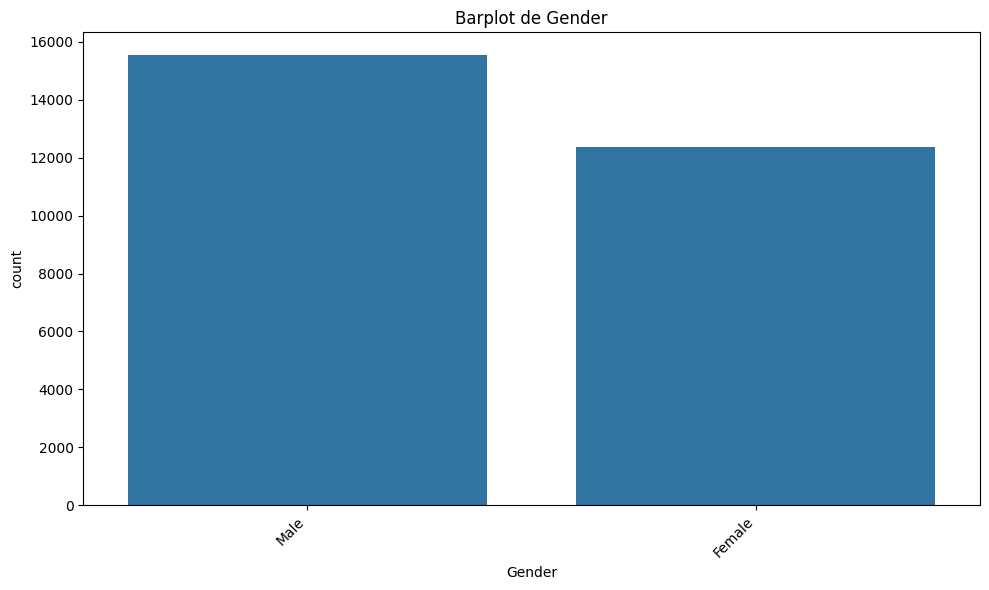

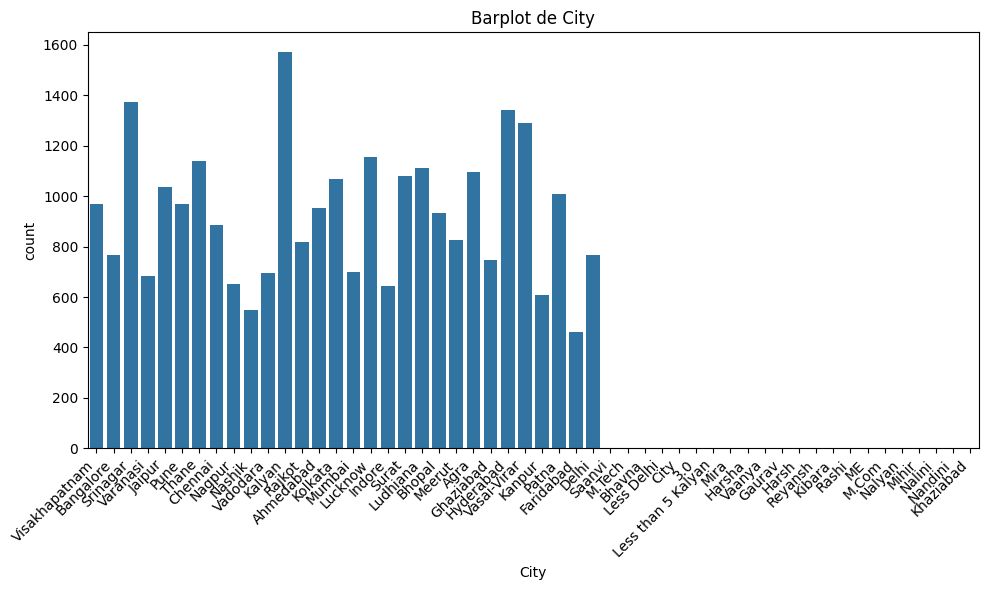

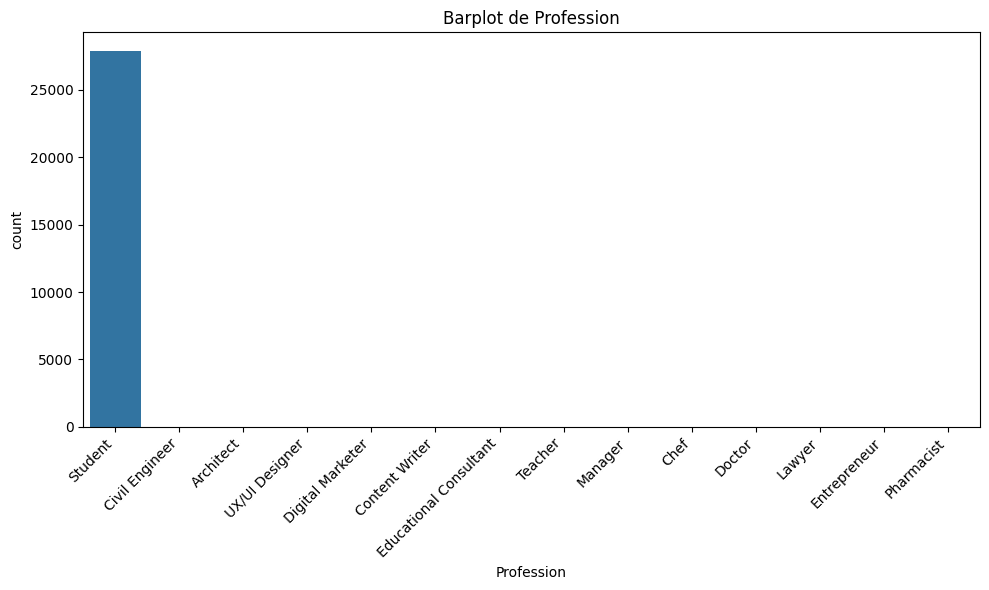

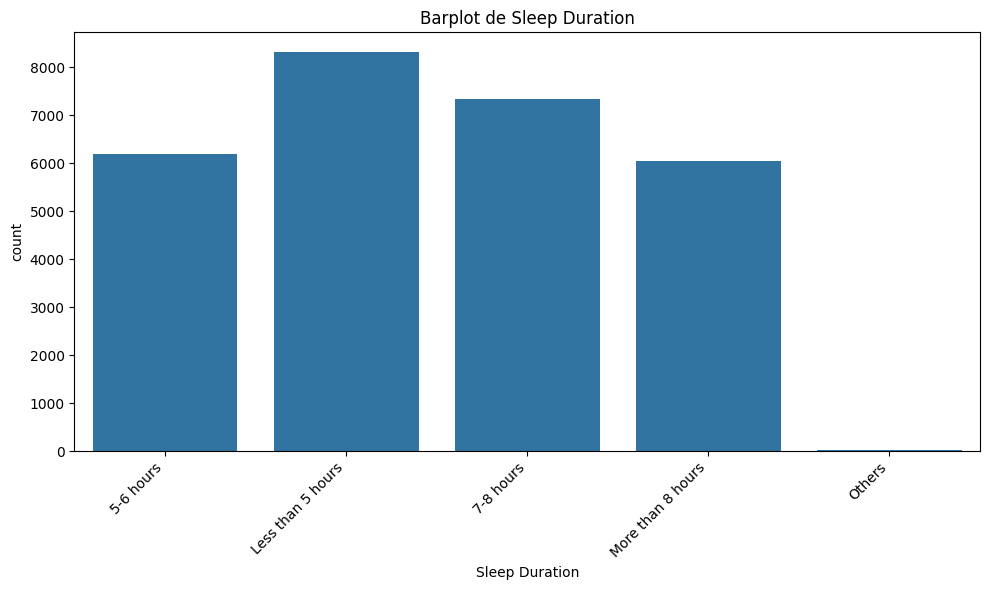

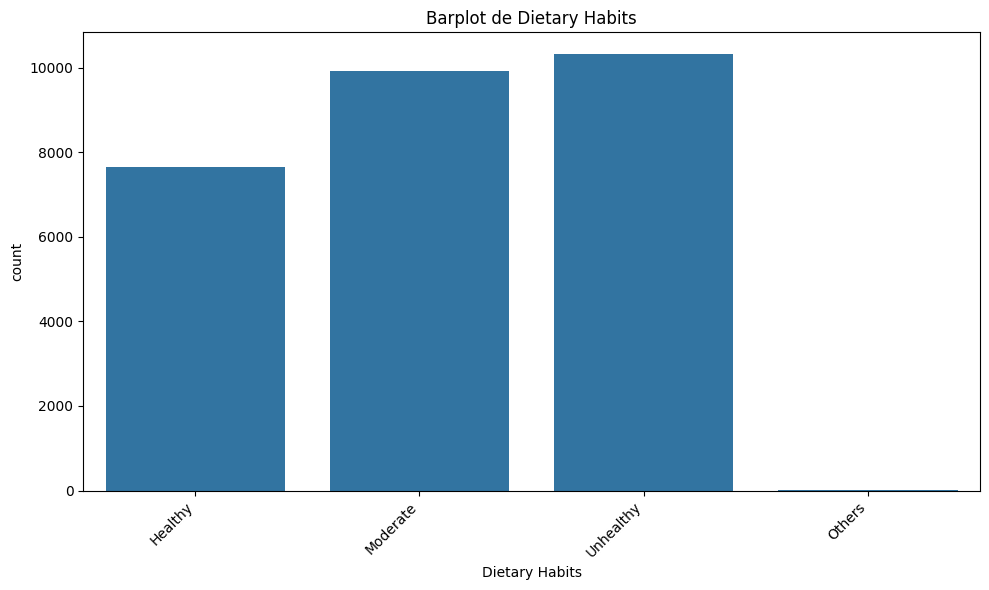

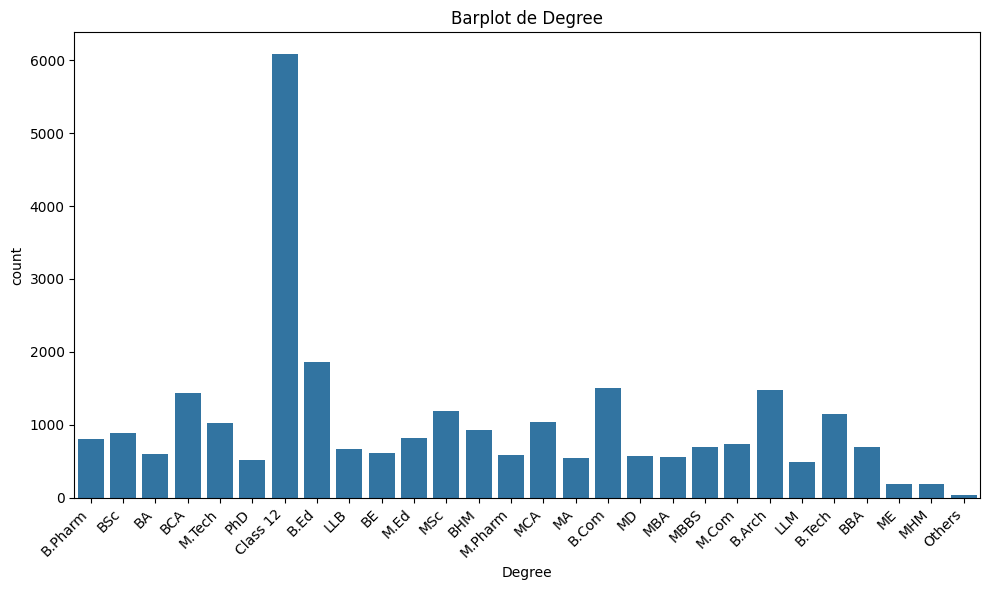

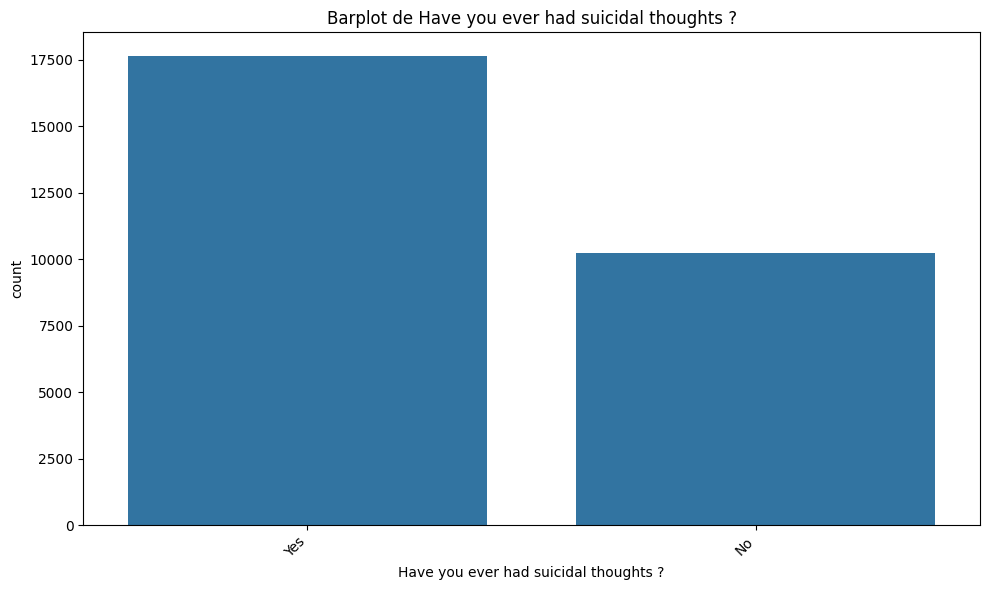

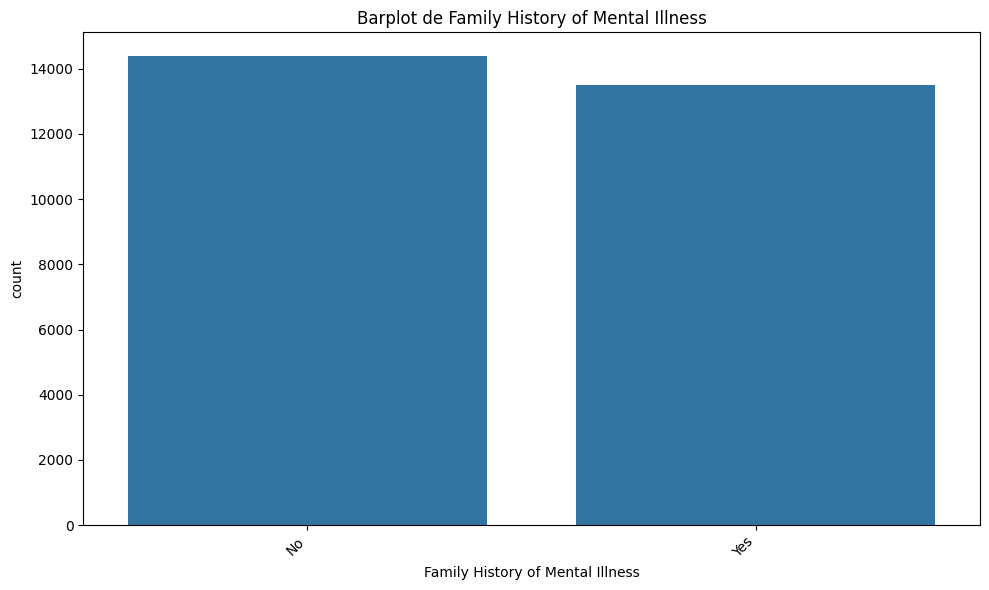

In [ ]:
for var in df_cat.columns:
    plt.figure(figsize=(10, 6))  # Ajustar el tamaño de la figura si es necesario
    sns.countplot(x=var, data=df)  # 'countplot' para barplot de frecuencia
    plt.title(f'Barplot de {var}')
    plt.xticks(rotation=45, ha='right')  # Rotar etiquetas del eje x para mejor legibilidad
    plt.tight_layout()  # Ajustar el diseño para evitar superposiciones
    plt.show()

## Pieplots

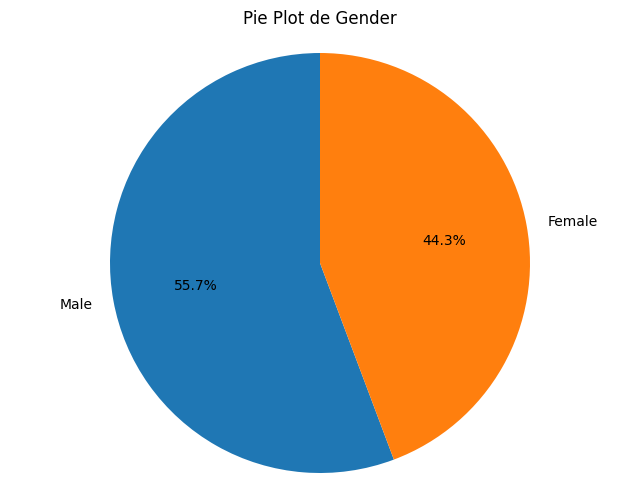

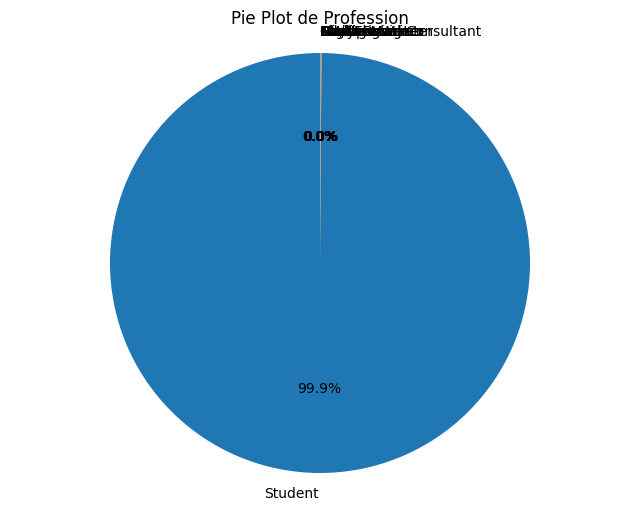

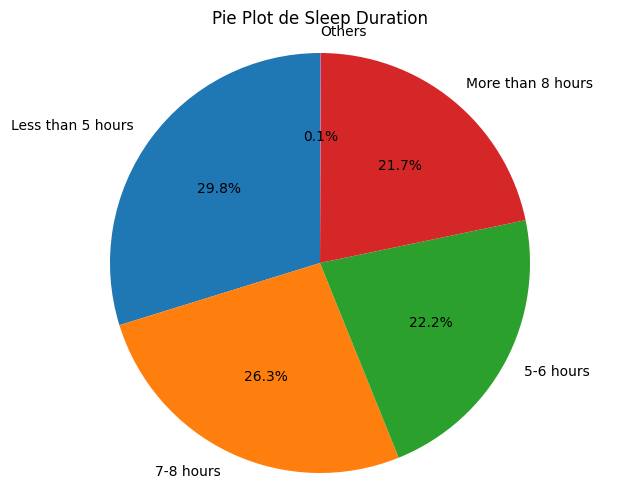

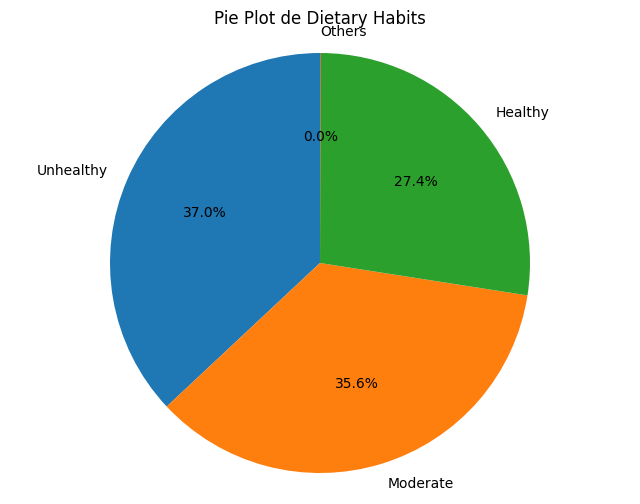

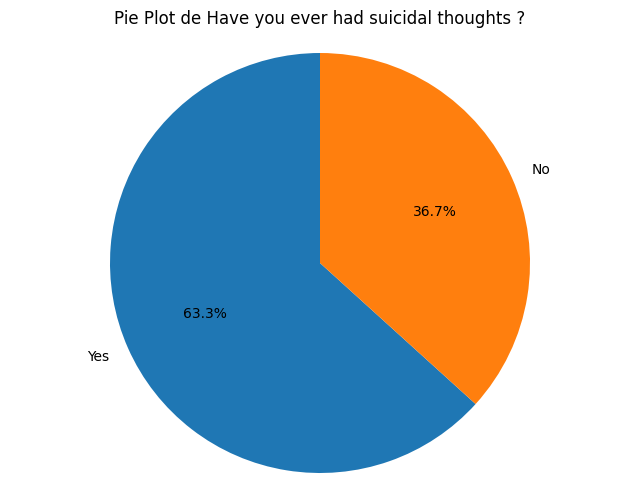

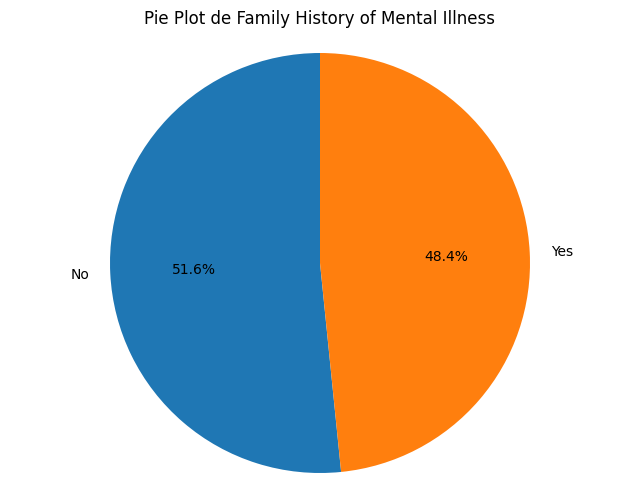

In [ ]:
# Iterar sobre las columnas categóricas y crear un pie plot para cada una
for columna in (df_cat.columns).drop(['City','Degree']):
    # Contar la frecuencia de cada categoría
    conteo_categorias = df_cat[columna].value_counts()

    # Crear el pie plot
    plt.figure(figsize=(8, 6))  # Ajustar el tamaño de la figura si es necesario
    plt.pie(conteo_categorias, labels=conteo_categorias.index, autopct='%1.1f%%', startangle=90)
    plt.title(f'Pie Plot de {columna}')
    plt.axis('equal')  # Para asegurar que el pie plot sea circular
    plt.show()

In [ ]:
df[df['Profession'] != 'Student'].shape

(31, 18)

In [ ]:
city_counts = df['City'].value_counts()
cities_less_than_200 = city_counts[city_counts < 200]
cities_less_than_200

,count
City,
Saanvi,2
Bhavna,2
City,2
Harsha,2
Less Delhi,1
M.Tech,1
3.0,1
Less than 5 Kalyan,1
Mira,1


## Histogramas Variables numéricas

In [ ]:
df['Depression'] = df['Depression'].astype('bool')

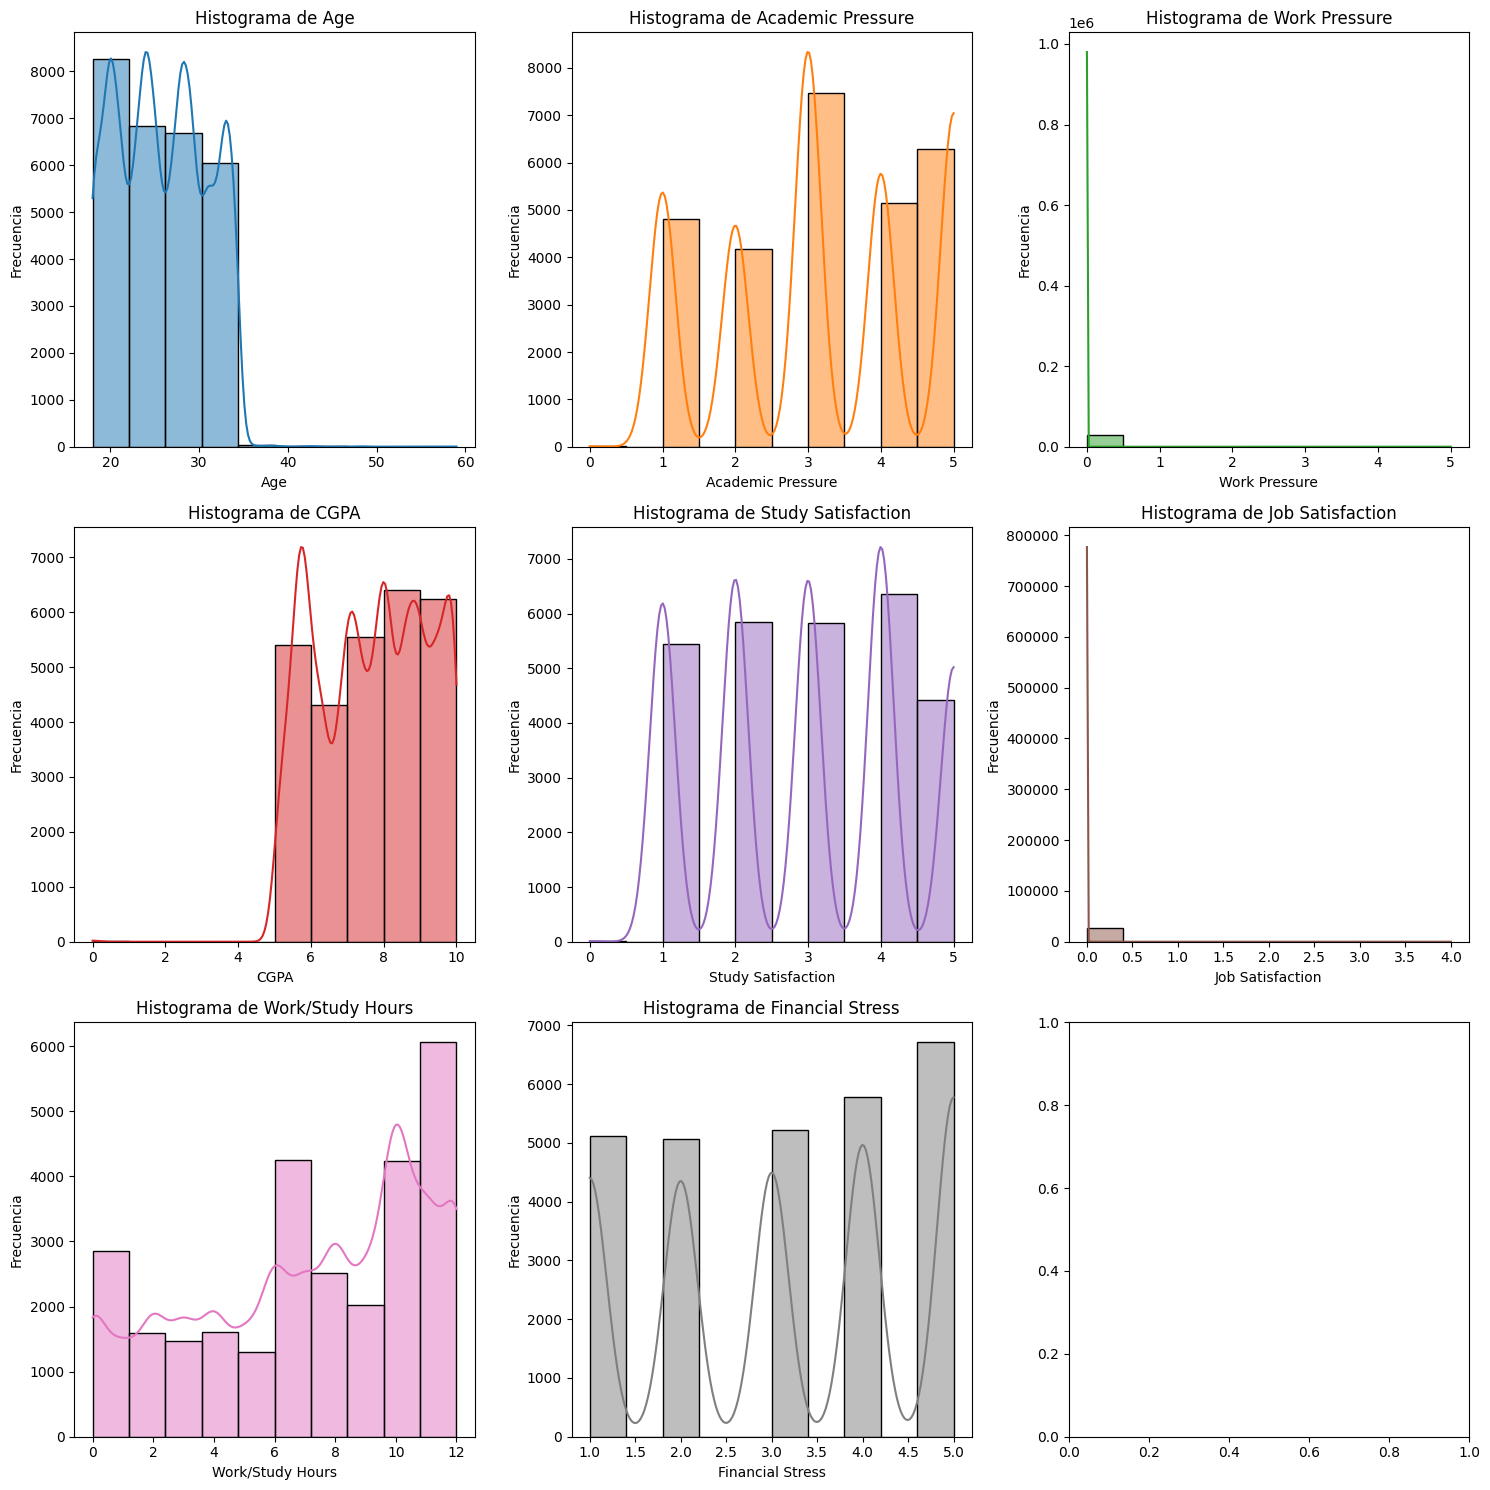

In [ ]:
# Definir el número de filas y columnas para los subplots
num_cols = 3  # Número de columnas
num_rows = int(np.ceil(len(df_num.columns) / num_cols))  # Número de filas

# Crear la figura y los subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

# Aplanar los axes para iterar fácilmente
axes = axes.flatten()

# Iterar sobre las columnas y crear los histogramas con Seaborn
for i, col in enumerate((df_num.columns).drop('Depression')):
    sns.histplot(df_num[col], bins=10, kde=True, color=sns.color_palette()[i], ax=axes[i])
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

## Boxplots

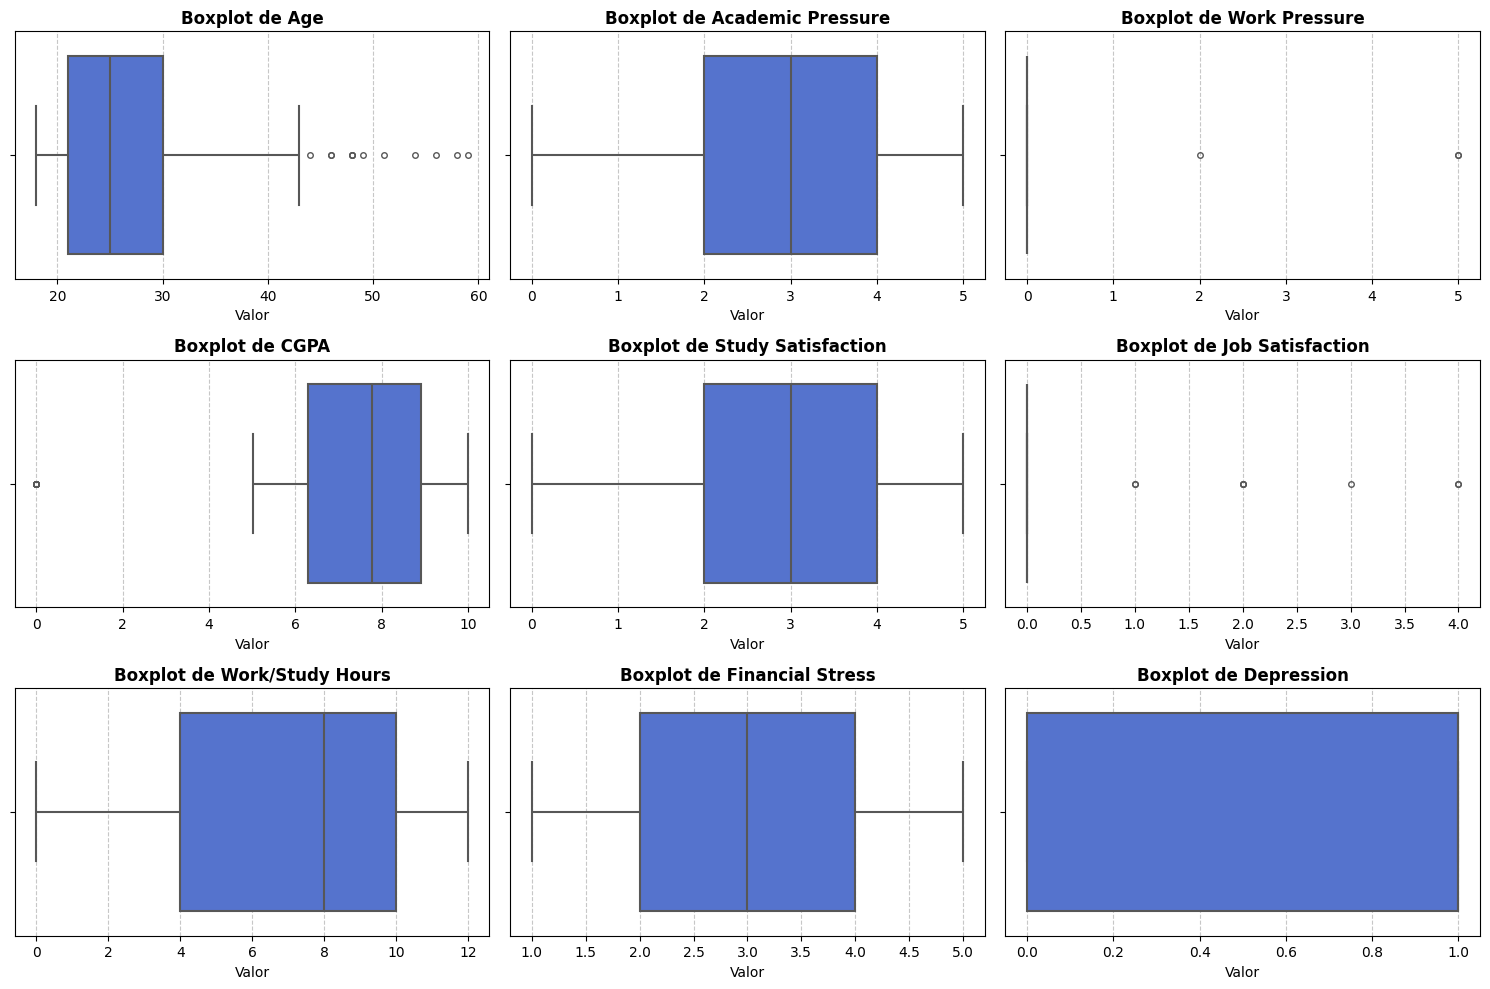

In [ ]:
# Generar boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

# Crear los boxplots en la misma estructura de subgráficos
for ax, var in zip(axes.flatten(), df_num.columns):
    sns.boxplot(x=df[var], ax=ax, color='royalblue', fliersize=4, linewidth=1.5)
    ax.set_title(f'Boxplot de {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.grid(axis='x', linestyle='--', alpha=0.7)

# Ajustar diseño para evitar superposiciones
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = df_num.corr()

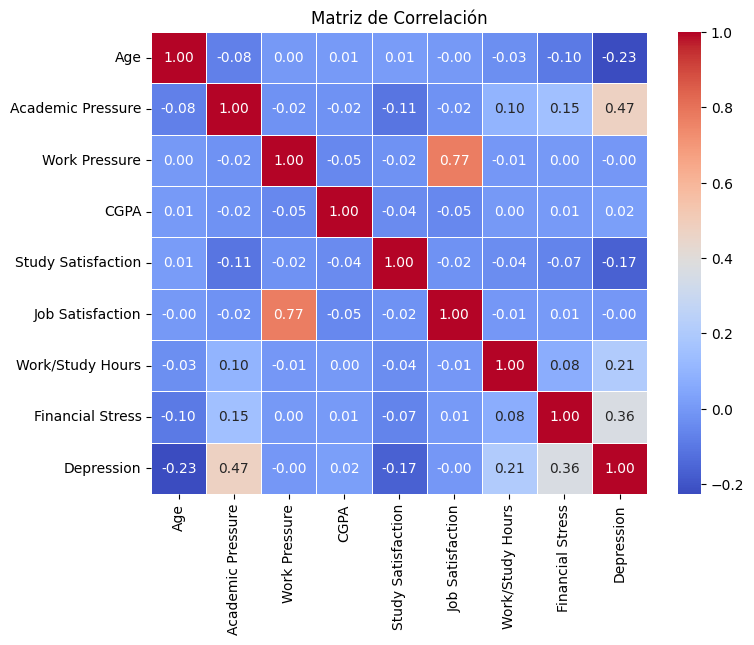

In [ ]:
# --- Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

##**Análisis multivariado**

In [ ]:
df['Depression'].value_counts()

,count
Depression,
True,16336
False,11565


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,15547
Female,12354


In [ ]:
df['Age'].value_counts()

,count
Age,
24.0,2258
20.0,2237
28.0,2133
29.0,1950
33.0,1893
25.0,1784
21.0,1726
23.0,1645
18.0,1587


In [ ]:
df['Have you ever had suicidal thoughts ?'].value_counts()

,count
Have you ever had suicidal thoughts ?,
Yes,17656
No,10245


In [ ]:
df['Family History of Mental Illness'].value_counts()

,count
Family History of Mental Illness,
No,14398
Yes,13503


**Countplot de estudiantes con depresión según el género**

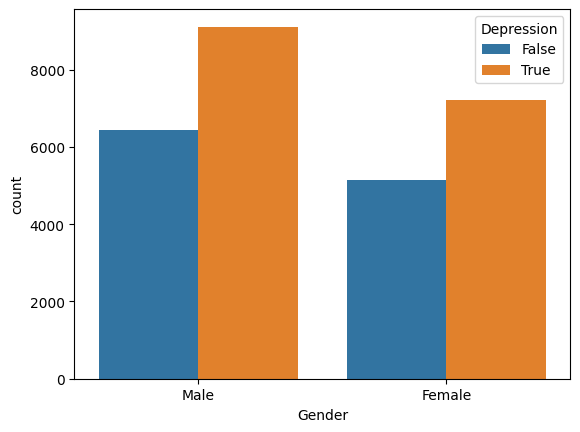

In [ ]:
sns.countplot(x='Gender', hue='Depression', data=df);

**Countplot de estudiantes con depresión según la presión academica**

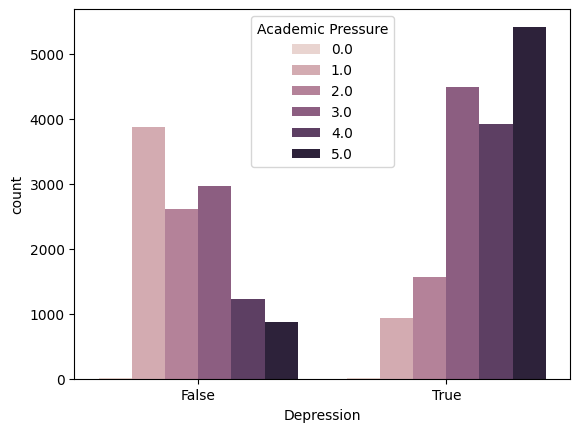

In [ ]:
sns.countplot(x='Depression', hue='Academic Pressure', data=df);

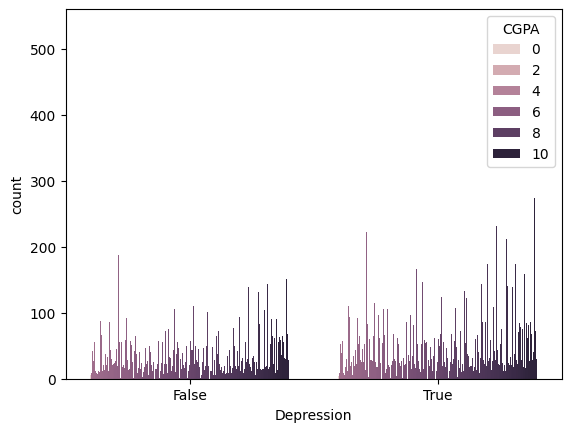

In [ ]:
sns.countplot(x='Depression', hue='CGPA', data=df);

**Countplot de estudiantes con depresión según pensamientos suicidas**

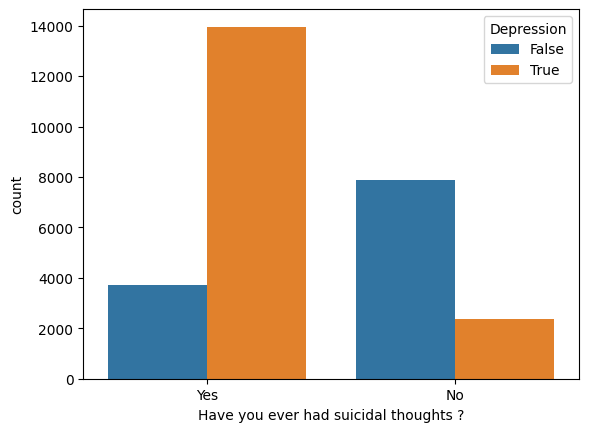

In [ ]:
sns.countplot(hue='Depression', x='Have you ever had suicidal thoughts ?', data=df);

**Countplot de estudiantes con depresión según antecedentes familiares**

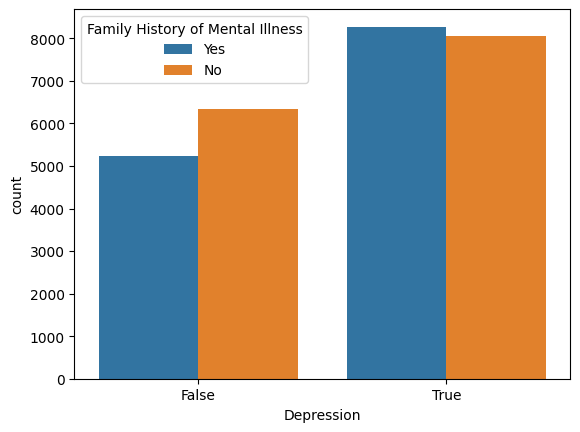

In [ ]:
sns.countplot(x='Depression', hue='Family History of Mental Illness', data=df);

**Boxplots de variables numéricas con respecto a 'Depression', incluyendo la clasificación por género**

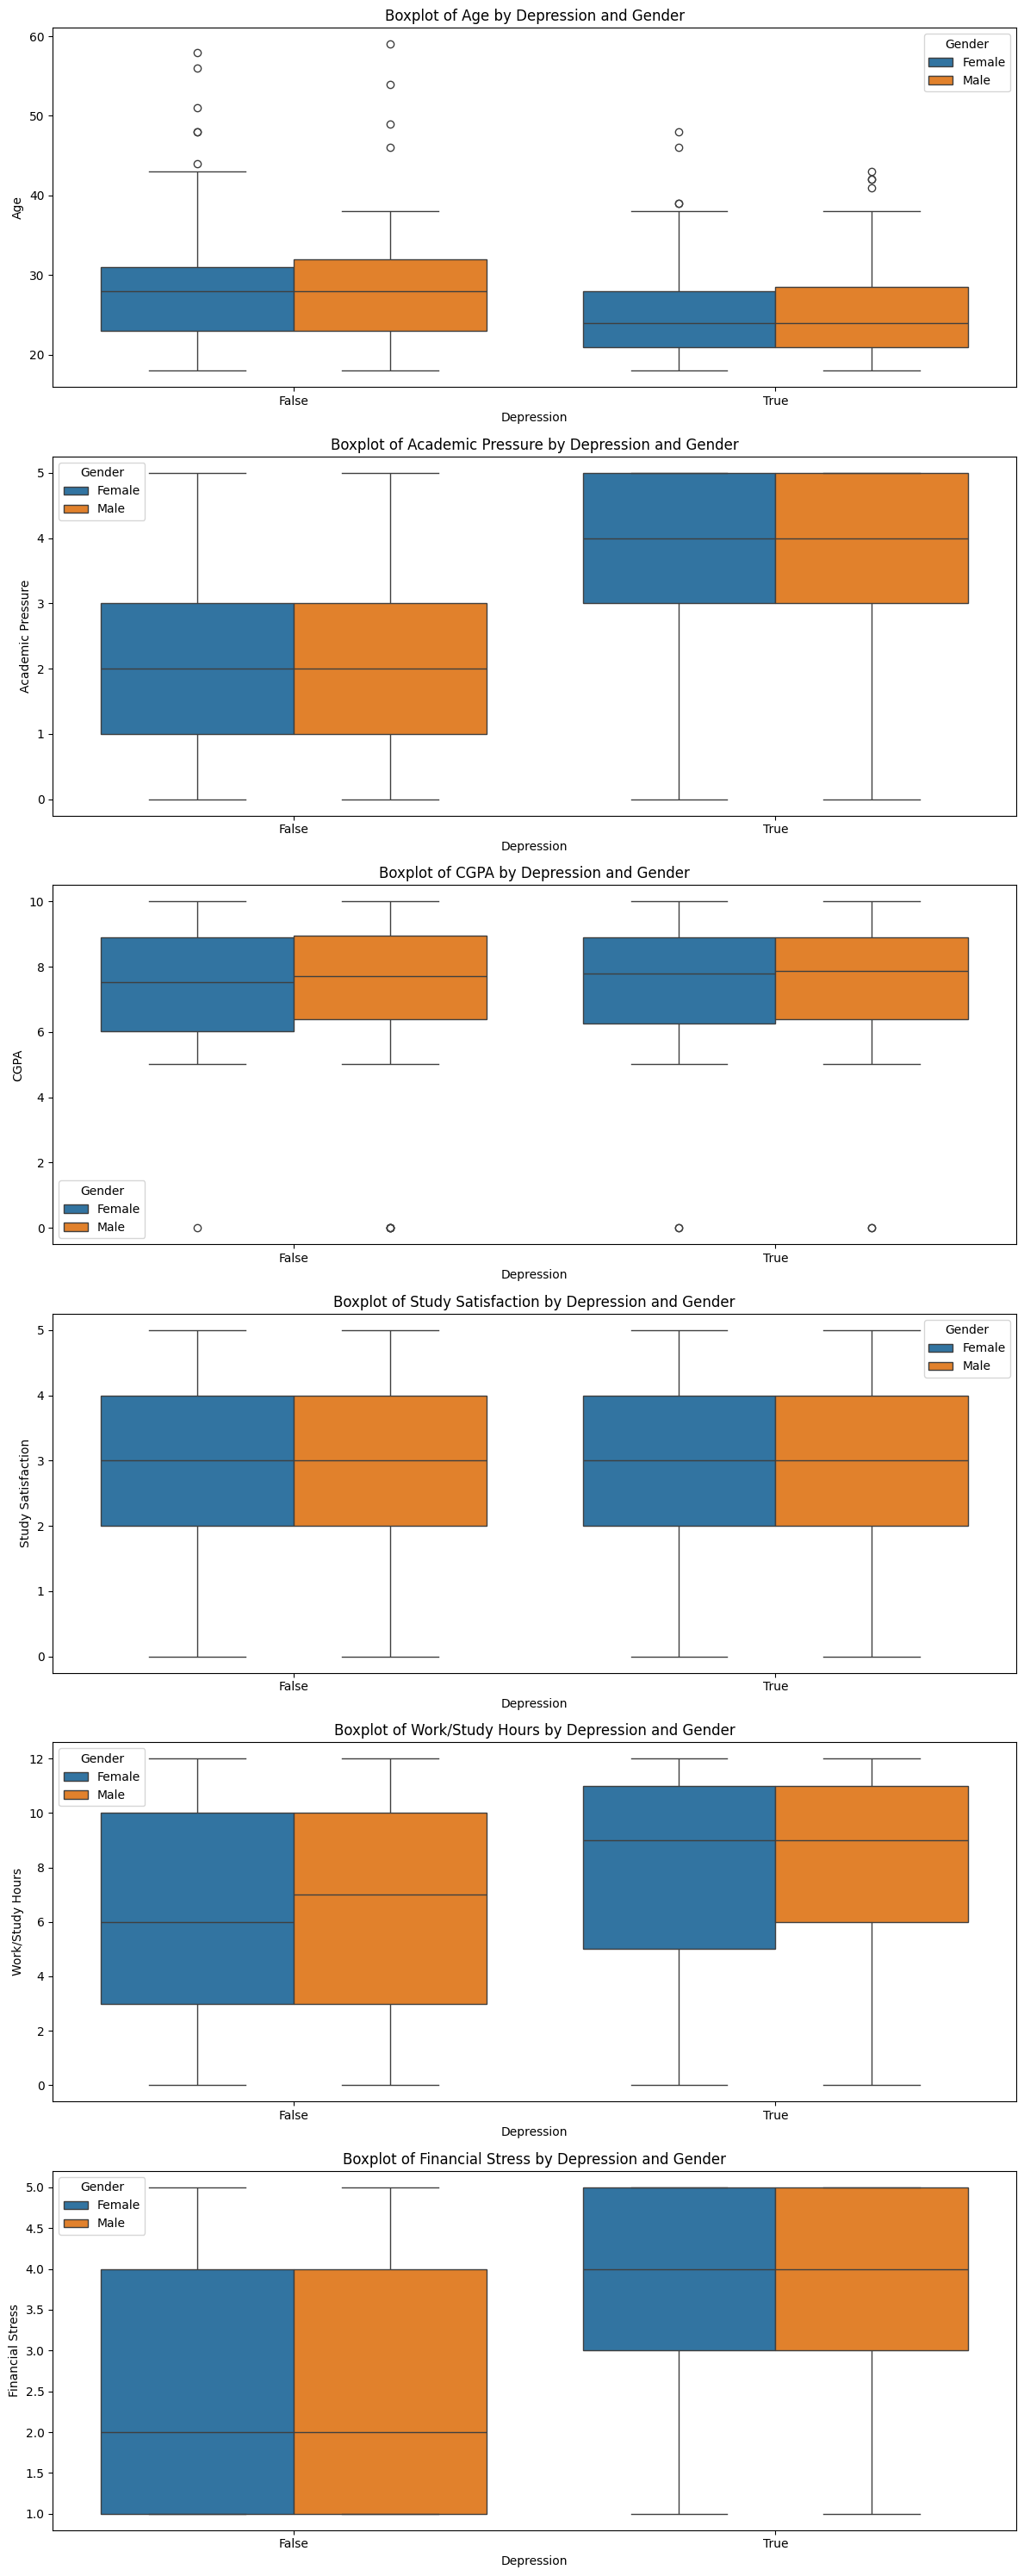

In [ ]:
# Selecciona las variables numéricas (excluyendo 'Depression' y las que no aportan)
numeric_vars = df.select_dtypes(include='number').columns.drop(['id', 'Work Pressure', 'Job Satisfaction'])
numeric_vars = [col for col in numeric_vars if col != 'Depression']

# Crea boxplots para cada variable numérica
plt.figure(figsize=(12, 5 * len(numeric_vars)))

for i, col in enumerate(numeric_vars):
    plt.subplot(len(numeric_vars), 1, i + 1)
    sns.boxplot(data=df, x='Depression', y=col, hue='Gender')
    plt.title(f'Boxplot of {col} by Depression and Gender')
    plt.xlabel('Depression')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Boxplots de variables numéricas con respecto a 'Depression', incluyendo la clasificación por horas de sueño**

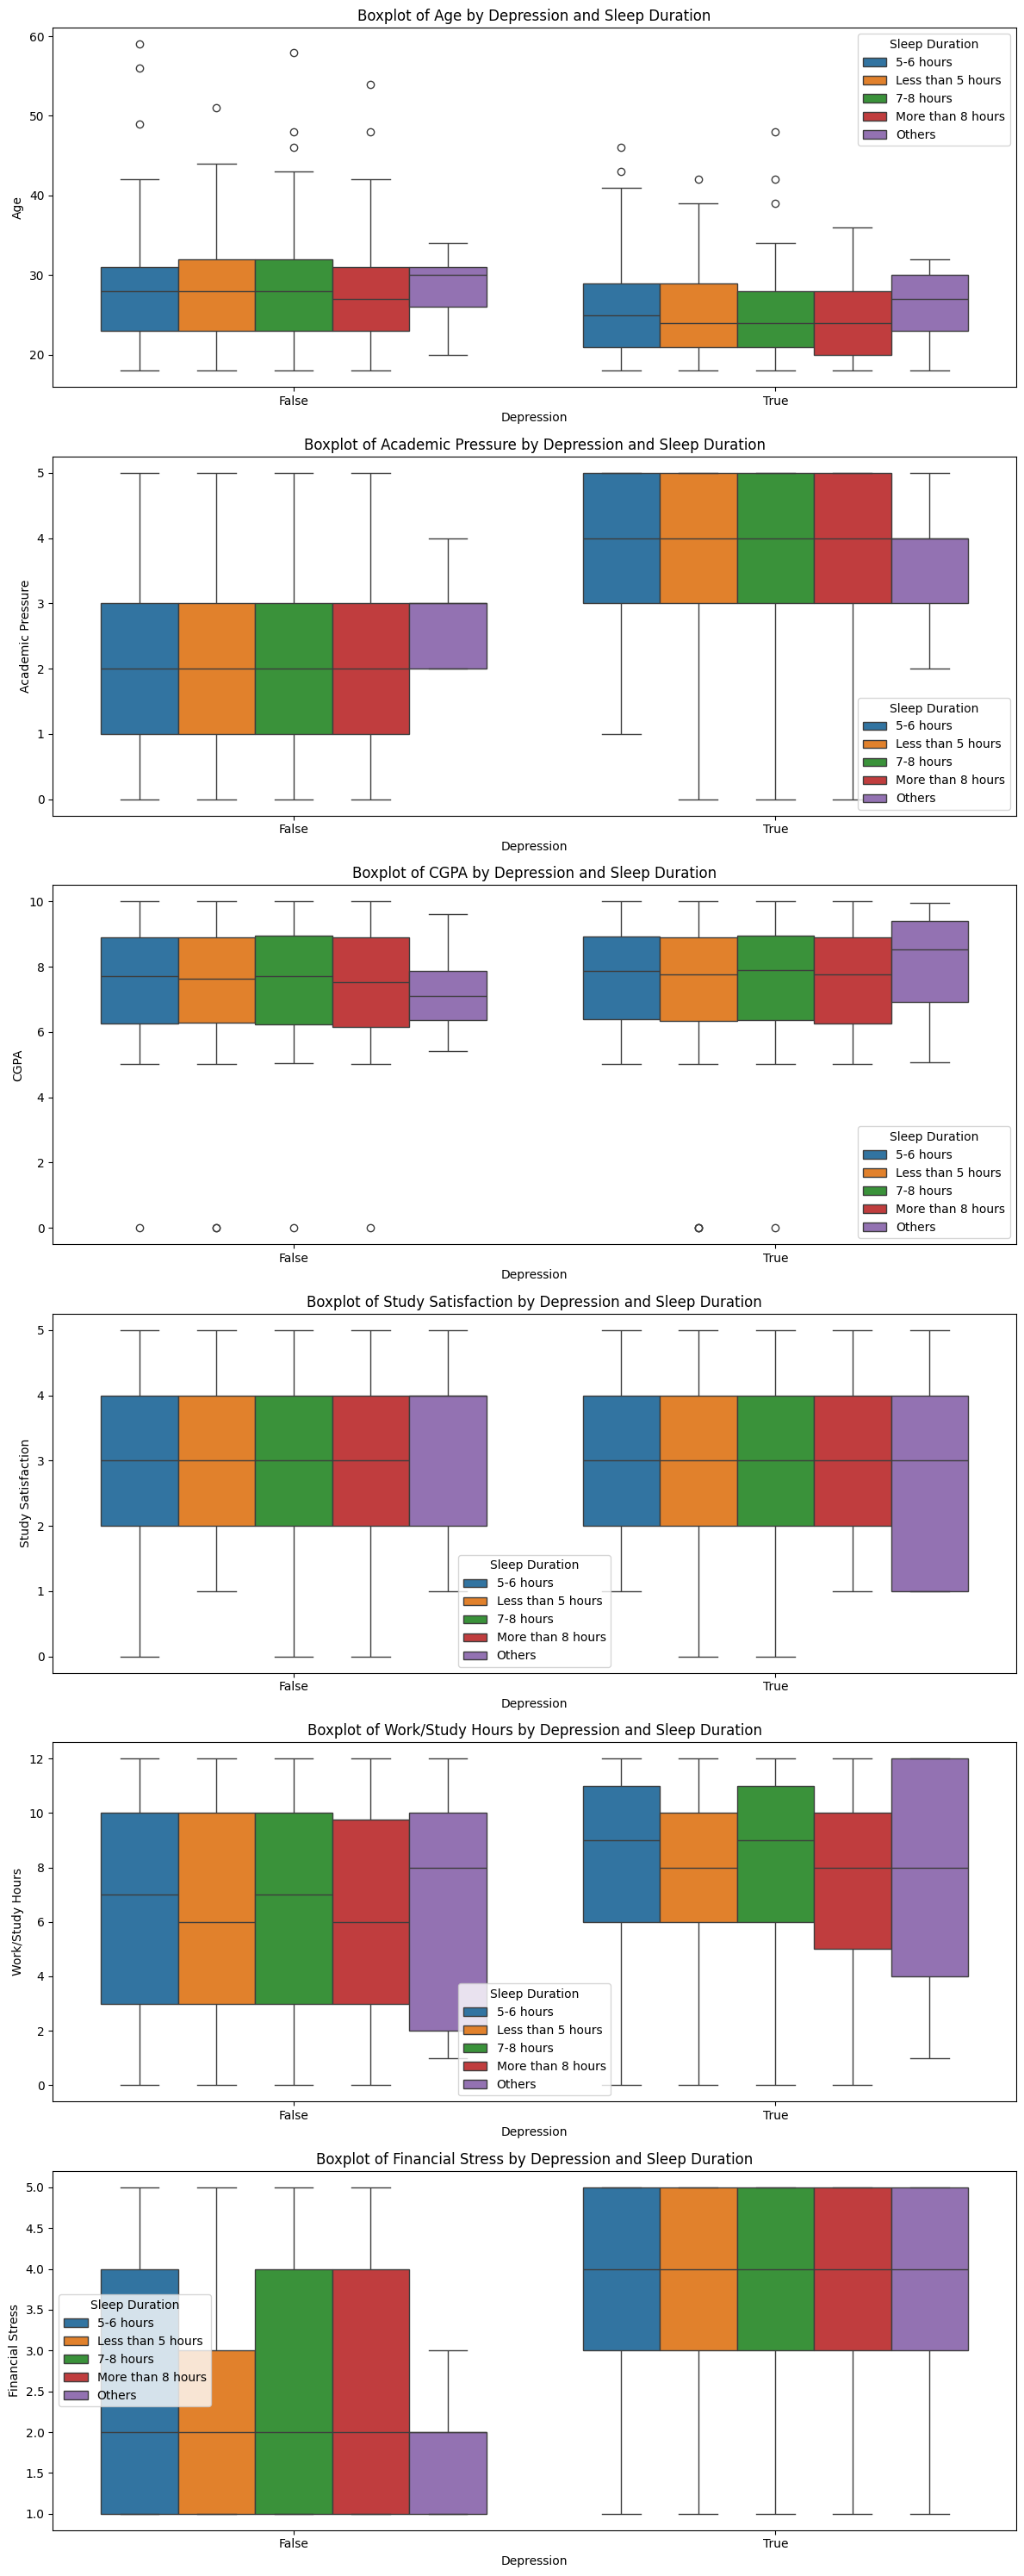

In [ ]:
# Crea boxplots para cada variable numérica
plt.figure(figsize=(12, 5 * len(numeric_vars)))

for i, col in enumerate(numeric_vars):
    plt.subplot(len(numeric_vars), 1, i + 1)
    sns.boxplot(data=df, x='Depression', y=col, hue='Sleep Duration')
    plt.title(f'Boxplot of {col} by Depression and Sleep Duration')
    plt.xlabel('Depression')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

**Boxplots de variables numéricas con respecto a 'Depression', incluyendo la clasificación por habitos de dieta**

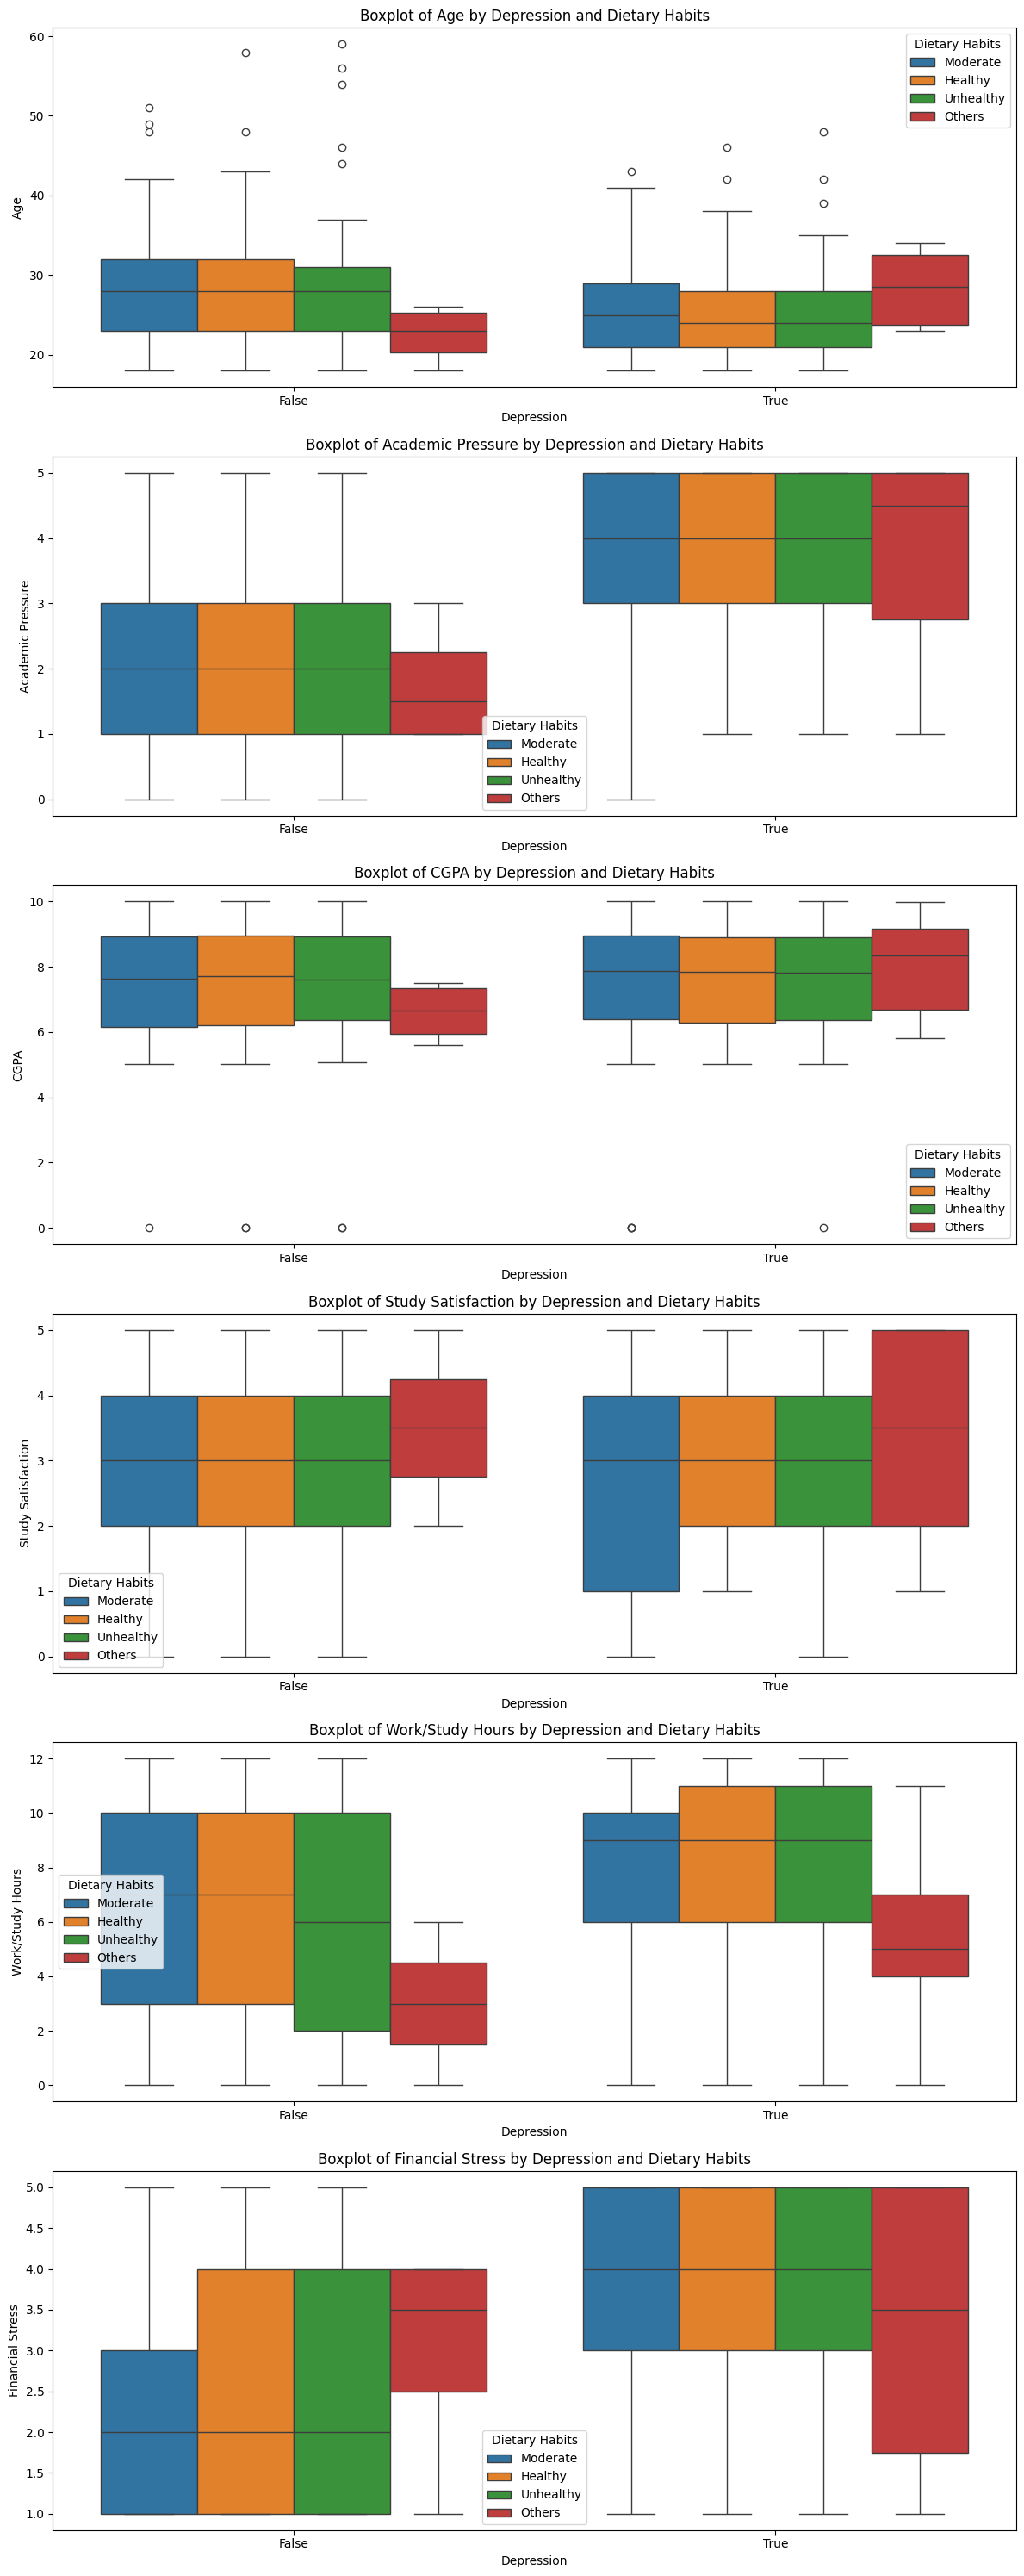

In [ ]:
# Crea boxplots para cada variable numérica
plt.figure(figsize=(12, 5 * len(numeric_vars)))

for i, col in enumerate(numeric_vars):
    plt.subplot(len(numeric_vars), 1, i + 1)
    sns.boxplot(data=df, x='Depression', y=col, hue='Dietary Habits')
    plt.title(f'Boxplot of {col} by Depression and Dietary Habits')
    plt.xlabel('Depression')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

#**3. Data Cleaning**

**Eliminar datos nulos**

In [ ]:
# Eliminar filas con valores nulos en la columna 'Financial Stress'
df_clean = df.copy()
df_clean = df.dropna(subset=['Financial Stress'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27898 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27898 non-null  int64  
 1   Gender                                 27898 non-null  object 
 2   Age                                    27898 non-null  float64
 3   City                                   27898 non-null  object 
 4   Profession                             27898 non-null  object 
 5   Academic Pressure                      27898 non-null  float64
 6   Work Pressure                          27898 non-null  float64
 7   CGPA                                   27898 non-null  float64
 8   Study Satisfaction                     27898 non-null  float64
 9   Job Satisfaction                       27898 non-null  float64
 10  Sleep Duration                         27898 non-null  object 
 11  Dietary

**Eliminar columnas de variables que no aportan**

In [ ]:
# Eliminar columnas 'Job Satisfaction' y 'Work Pressure'
df_clean = df_clean.drop(columns=['id','Job Satisfaction', 'Work Pressure'])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27898 entries, 0 to 27900
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27898 non-null  object 
 1   Age                                    27898 non-null  float64
 2   City                                   27898 non-null  object 
 3   Profession                             27898 non-null  object 
 4   Academic Pressure                      27898 non-null  float64
 5   CGPA                                   27898 non-null  float64
 6   Study Satisfaction                     27898 non-null  float64
 7   Sleep Duration                         27898 non-null  object 
 8   Dietary Habits                         27898 non-null  object 
 9   Degree                                 27898 non-null  object 
 10  Have you ever had suicidal thoughts ?  27898 non-null  object 
 11  Work/St

**Conservar solo los registros de los estudiantes**

In [ ]:
# Filtrar registros donde la profesión sea 'Student'
df_clean= df_clean[df_clean['Profession'] == 'Student']
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27867 entries, 0 to 27900
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27867 non-null  object 
 1   Age                                    27867 non-null  float64
 2   City                                   27867 non-null  object 
 3   Profession                             27867 non-null  object 
 4   Academic Pressure                      27867 non-null  float64
 5   CGPA                                   27867 non-null  float64
 6   Study Satisfaction                     27867 non-null  float64
 7   Sleep Duration                         27867 non-null  object 
 8   Dietary Habits                         27867 non-null  object 
 9   Degree                                 27867 non-null  object 
 10  Have you ever had suicidal thoughts ?  27867 non-null  object 
 11  Work/St

**Verificar si hay registros duplicados**

In [ ]:
# Verificar si hay filas duplicadas
duplicados = df_clean.duplicated()

# Mostrar cuántas filas duplicadas hay
print(f"Número de filas duplicadas: {duplicados.sum()}")

Número de filas duplicadas: 0


**Observación:** En este caso no existen registros duplicados dentro del dataset con el que estamos trabajando.

**Limpiar la columa 'City'**

In [ ]:
# Ver todas las ciudades únicas en el dataset
ciudades_unicas = df['City'].unique()
print("Ciudades únicas en el dataset:")
print(ciudades_unicas)


Ciudades únicas en el dataset:
['Visakhapatnam' 'Bangalore' 'Srinagar' 'Varanasi' 'Jaipur' 'Pune' 'Thane'
 'Chennai' 'Nagpur' 'Nashik' 'Vadodara' 'Kalyan' 'Rajkot' 'Ahmedabad'
 'Kolkata' 'Mumbai' 'Lucknow' 'Indore' 'Surat' 'Ludhiana' 'Bhopal'
 'Meerut' 'Agra' 'Ghaziabad' 'Hyderabad' 'Vasai-Virar' 'Kanpur' 'Patna'
 'Faridabad' 'Delhi' 'Saanvi' 'M.Tech' 'Bhavna' 'Less Delhi' 'City' '3.0'
 'Less than 5 Kalyan' 'Mira' 'Harsha' 'Vaanya' 'Gaurav' 'Harsh' 'Reyansh'
 'Kibara' 'Rashi' 'ME' 'M.Com' 'Nalyan' 'Mihir' 'Nalini' 'Nandini'
 'Khaziabad']


In [ ]:
# Contar la cantidad de registros por ciudad
conteo_ciudades = df['City'].value_counts()

print(conteo_ciudades)


City
Kalyan                1570
Srinagar              1372
Hyderabad             1340
Vasai-Virar           1290
Lucknow               1155
Thane                 1139
Ludhiana              1111
Agra                  1094
Surat                 1078
Kolkata               1066
Jaipur                1036
Patna                 1007
Visakhapatnam          969
Pune                   968
Ahmedabad              951
Bhopal                 934
Chennai                885
Meerut                 825
Rajkot                 816
Delhi                  768
Bangalore              767
Ghaziabad              745
Mumbai                 699
Vadodara               694
Varanasi               685
Nagpur                 651
Indore                 643
Kanpur                 609
Nashik                 547
Faridabad              461
Saanvi                   2
Bhavna                   2
City                     2
Harsha                   2
Less Delhi               1
M.Tech                   1
3.0                    

Con esto se puede tomar la decisión de borrar los registros que contienen ciudades inválidas, las razones son:


* Nombres como "M.Tech", "3.0", "ME", "Less Delhi", "Nalyan", "Kibara" o "Vaanya" claramente no son ciudades.

* No representan una cantidad significativa de datos (1 o 2 registros).

* Conservarlos no aporta valor y puede distorsionar análisis como segmentaciones por ciudad.




In [ ]:
# Obtener el conteo de registros por ciudad
conteo_ciudades = df_clean['City'].value_counts()

# Identificar las ciudades que tienen más de 2 registros
ciudades_validas = conteo_ciudades[conteo_ciudades > 2].index

# Filtrar df_clean para conservar solo las ciudades válidas
df_clean = df_clean[df_clean['City'].isin(ciudades_validas)].copy()

# Mostrar la cantidad de registros resultantes
print(f"Registros después de eliminar ciudades con 2 o menos entradas: {df_clean.shape[0]}")


Registros después de eliminar ciudades con 2 o menos entradas: 27841


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27841 entries, 0 to 27900
Data columns (total 15 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27841 non-null  object 
 1   Age                                    27841 non-null  float64
 2   City                                   27841 non-null  object 
 3   Profession                             27841 non-null  object 
 4   Academic Pressure                      27841 non-null  float64
 5   CGPA                                   27841 non-null  float64
 6   Study Satisfaction                     27841 non-null  float64
 7   Sleep Duration                         27841 non-null  object 
 8   Dietary Habits                         27841 non-null  object 
 9   Degree                                 27841 non-null  object 
 10  Have you ever had suicidal thoughts ?  27841 non-null  object 
 11  Work/St

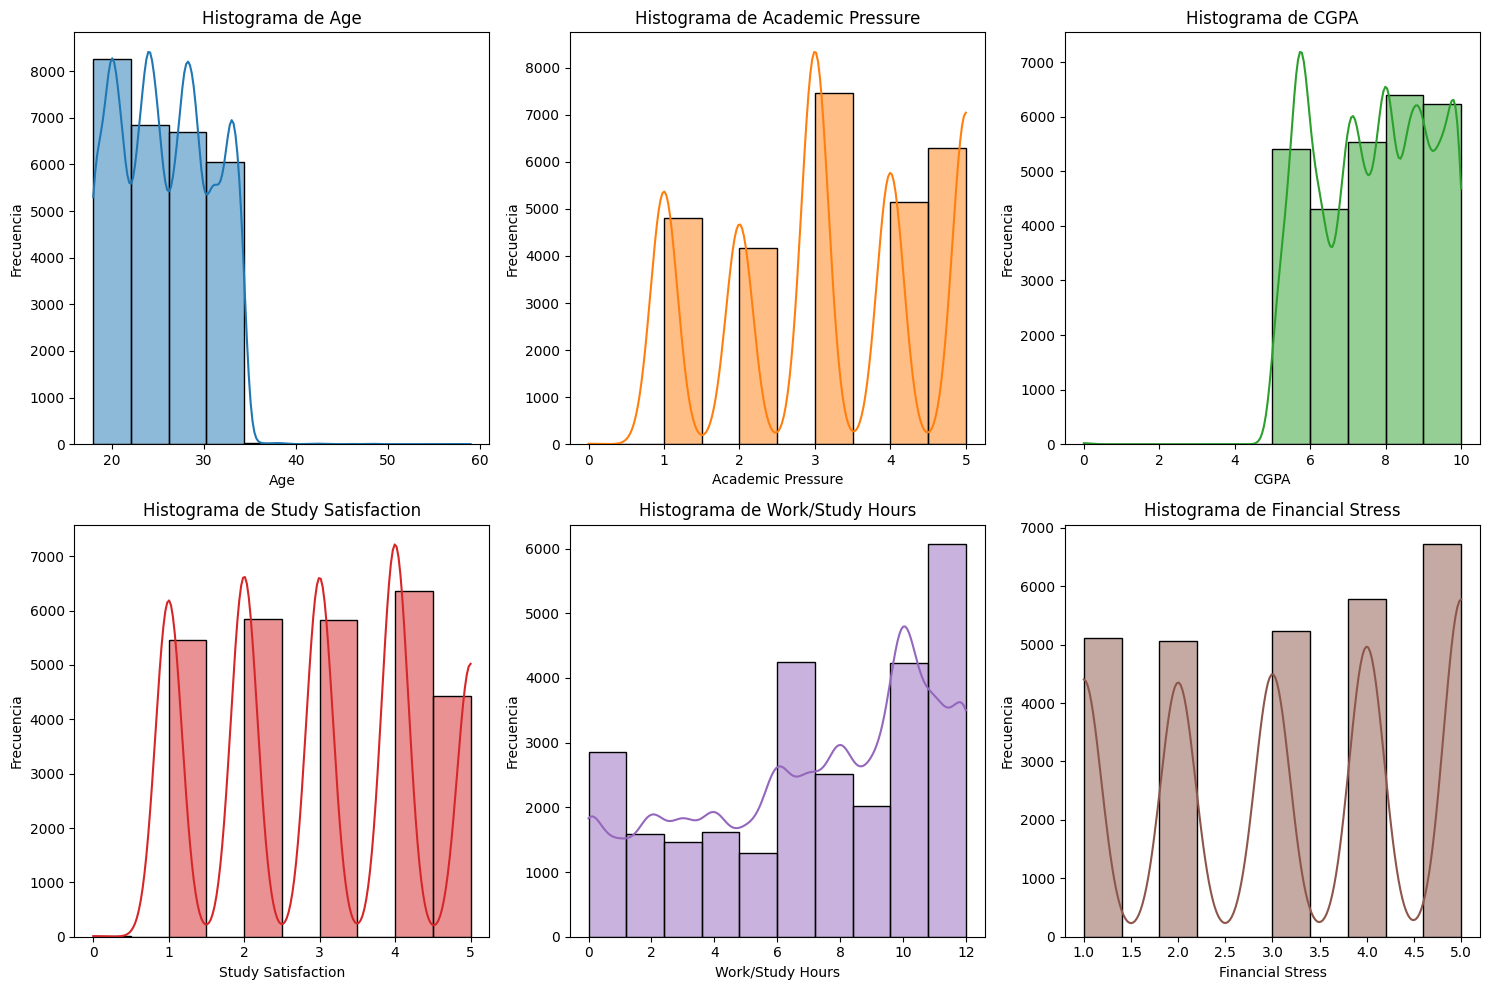

In [ ]:
# Definir el número de filas y columnas para los subplots
num_cols = 3  # Número de columnas
num_rows = 2  # Número de filas

# Crear la figura y los subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

# Aplanar los axes para iterar fácilmente
axes = axes.flatten()
df_clean_num = df_clean.select_dtypes(include=['int64', 'float64'])
# Iterar sobre las columnas y crear los histogramas con Seaborn
for i, col in enumerate((df_clean_num.columns)):
    sns.histplot(df_num[col], bins=10, kde=True, color=sns.color_palette()[i], ax=axes[i])
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

La columna Profession solo contiene el valor 'Students' Por lo tanto ya no es relevante y una vez hecho el filtro se puede eliminar

In [ ]:
df_clean.drop('Profession', axis=1, inplace=True)

In [ ]:
# Copia del DataFrame
df_clean = df_clean.copy()

# Normalizar nombres de columnas: minúsculas, sin espacios ni símbolos
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('?', '', regex=False)
    .str.replace('/', '_')
)

# Renombrar algunas columnas con nombres más claros
rename_map = {
    'have_you_ever_had_suicidal_thoughts_': 'suicidal_thoughts',
    'family_history_of_mental_illness': 'mental_illness_history',
    'sleep_duration': 'sleep_hours',
    'dietary_habits': 'diet',
    'work_study_hours': 'hours_dedicated',
    'study_satisfaction': 'study_satisfaction_level'
}

df_clean.rename(columns=rename_map, inplace=True)

# Mostrar nombres de columnas finales
df_clean.columns.tolist()

['gender',
 'age',
 'city',
 'academic_pressure',
 'cgpa',
 'study_satisfaction_level',
 'sleep_hours',
 'diet',
 'degree',
 'suicidal_thoughts',
 'hours_dedicated',
 'financial_stress',
 'mental_illness_history',
 'depression']

Las columnas study_satisfaction_level, cgpa, financial_stress, academic_pressure son niveles del 0 al 5, o en caso de l cgpa del 1 al 10, por lo tanto pueden ser categorizadas.

In [ ]:
bins_5 = [-0.1, 1.5, 2.5, 3.5, 5]  # límites para 4 niveles
labels_5 = ['bajo', 'medio', 'medio alto', 'alto']

bins_10 = [-0.1, 2.5, 5, 7.5, 10]
labels_10 = ['bajo', 'medio', 'medio alto', 'alto']

In [ ]:
vars_0_5 = ['study_satisfaction_level', 'financial_stress', 'academic_pressure']
for var in vars_0_5:
    df_clean[f'{var}_cat'] = pd.cut(df_clean[var], bins=bins_5, labels=labels_5)

# Variable CGPA (escala 0 a 10)
df_clean['cgpa_cat'] = pd.cut(df_clean['cgpa'], bins=bins_10, labels=labels_10)
df_clean.drop(vars_0_5 + ['cgpa'], axis=1, inplace=True)
df_clean

,gender,age,city,sleep_hours,diet,degree,suicidal_thoughts,hours_dedicated,mental_illness_history,depression,study_satisfaction_level_cat,financial_stress_cat,academic_pressure_cat,cgpa_cat
0,Male,33.0,Visakhapatnam,5-6 hours,Healthy,B.Pharm,Yes,3.0,No,True,medio,bajo,alto,alto
1,Female,24.0,Bangalore,5-6 hours,Moderate,BSc,No,3.0,Yes,False,alto,medio,medio,medio alto
2,Male,31.0,Srinagar,Less than 5 hours,Healthy,BA,No,9.0,Yes,False,alto,bajo,medio alto,medio alto
3,Female,28.0,Varanasi,7-8 hours,Moderate,BCA,Yes,4.0,Yes,True,medio,alto,medio alto,medio alto
4,Female,25.0,Jaipur,5-6 hours,Moderate,M.Tech,Yes,1.0,No,False,medio alto,bajo,alto,alto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27.0,Surat,5-6 hours,Unhealthy,Class 12,Yes,7.0,Yes,False,alto,bajo,alto,medio alto
27897,Male,27.0,Ludhiana,Less than 5 hours,Healthy,MSc,No,0.0,Yes,False,medio alto,medio alto,medio,alto
27898,Male,31.0,Faridabad,5-6 hours,Unhealthy,MD,No,12.0,No,False,alto,medio,medio alto,medio alto
27899,Female,18.0,Ludhiana,Less than 5 hours,Healthy,Class 12,Yes,10.0,No,True,medio,alto,alto,medio alto


#### Categorizar variable degree

In [ ]:
degree_mapping = {
    'Class 12': 'Class 12',
    'BA': 'Bachelor',
    'B.Com': 'Bachelor',
    'BSc': 'Bachelor',
    'B.Ed': 'Bachelor',
    'BBA': 'Bachelor',
    'BCA': 'Bachelor',
    'B.Tech': 'Bachelor',
    'BE': 'Bachelor',
    'B.Arch': 'Bachelor',
    'B.Pharm': 'Bachelor',
    'BHM': 'Bachelor',
    'LLB': 'Bachelor',
    'MBBS': 'Bachelor',
    'MA': 'Master',
    'M.Com': 'Master',
    'M.Ed': 'Master',
    'MSc': 'Master',
    'MBA': 'Master',
    'MCA': 'Master',
    'ME': 'Master',
    'M.Tech': 'Master',
    'MHM': 'Master',
    'M.Pharm': 'Master',
    'LLM': 'Master',
    'MD': 'Doctorate',
    'PhD': 'Doctorate',
    'Others': 'Others'
}

In [ ]:
df_clean['degree_grouped'] = df_clean['degree'].map(degree_mapping)
df_clean = df_clean.drop('degree', axis=1)

# Validación rápida
print(df_clean['degree_grouped'].unique())
print("\nValue counts for the new 'degree_grouped' column:")
df_clean['degree_grouped'].value_counts()

['Bachelor' 'Master' 'Doctorate' 'Class 12' 'Others']

Value counts for the new 'degree_grouped' column:


,count
degree_grouped,
Bachelor,13303
Master,7339
Class 12,6075
Doctorate,1089
Others,35


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27841 entries, 0 to 27900
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   gender                        27841 non-null  object  
 1   age                           27841 non-null  float64 
 2   city                          27841 non-null  object  
 3   sleep_hours                   27841 non-null  object  
 4   diet                          27841 non-null  object  
 5   suicidal_thoughts             27841 non-null  object  
 6   hours_dedicated               27841 non-null  float64 
 7   mental_illness_history        27841 non-null  object  
 8   depression                    27841 non-null  bool    
 9   study_satisfaction_level_cat  27841 non-null  category
 10  financial_stress_cat          27841 non-null  category
 11  academic_pressure_cat         27841 non-null  category
 12  cgpa_cat                      27841 non-null  categ

### Eliminar suicidal_thoughts

Con el fin de probar que tanto afecta esta variable a los resultados se eliminará del dataframe limpio.

In [ ]:
df_clean = df_clean.drop('suicidal_thoughts', axis=1)

#**4. Modelo de regresión logística**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df_clean.drop('depression', axis=1)
y = df_clean['depression']


Train set:
depression
True     58.518062
False    41.481938
Name: proportion, dtype: float64


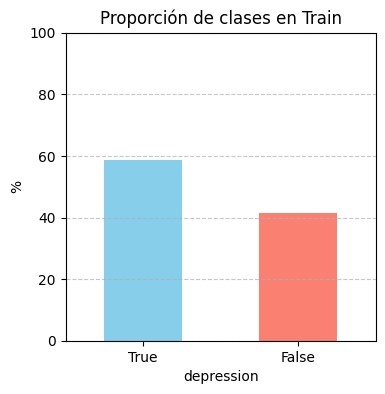


Validation set:
depression
True     58.524904
False    41.475096
Name: proportion, dtype: float64


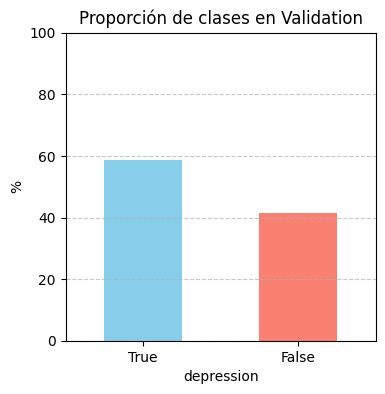


Test set:
depression
True     58.510893
False    41.489107
Name: proportion, dtype: float64


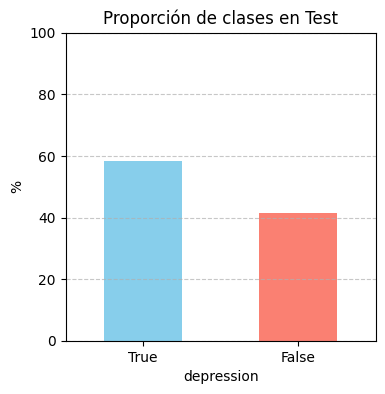

In [ ]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# División inicial: train (70%) y temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# División de temp en validación (15%) y test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# Función para mostrar proporción de clases
def mostrar_proporciones(etiquetas, nombre):
    porcentajes = etiquetas.value_counts(normalize=True) * 100
    print(f"\n{name} set:")
    print(porcentajes)

    # Graficar
    plt.figure(figsize=(4, 4))
    porcentajes.plot(kind='bar', color=['skyblue', 'salmon'])
    plt.title(f'Proporción de clases en {nombre}')
    plt.ylabel('%')
    plt.xticks(rotation=0)
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Mostrar proporciones
for name, split in zip(["Train", "Validation", "Test"], [y_train, y_val, y_test]):
    mostrar_proporciones(split, name)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix, f1_score,RocCurveDisplay, roc_auc_score
from scipy.stats import loguniform
from sklearn.model_selection import GridSearchCV

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27841 entries, 0 to 27900
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   gender                        27841 non-null  object  
 1   age                           27841 non-null  float64 
 2   city                          27841 non-null  object  
 3   sleep_hours                   27841 non-null  object  
 4   diet                          27841 non-null  object  
 5   hours_dedicated               27841 non-null  float64 
 6   mental_illness_history        27841 non-null  object  
 7   depression                    27841 non-null  bool    
 8   study_satisfaction_level_cat  27841 non-null  category
 9   financial_stress_cat          27841 non-null  category
 10  academic_pressure_cat         27841 non-null  category
 11  cgpa_cat                      27841 non-null  category
 12  degree_grouped                27841 non-null  objec

In [ ]:
num_vars = [
    'age', 'hours_dedicated'
]


In [ ]:
categorical_columns = df_clean.select_dtypes(include=['object','category']).columns.tolist()
unique_values = {col: df_clean[col].unique() for col in categorical_columns}
unique_values

{'gender': array(['Male', 'Female'], dtype=object),
 'city': array(['Visakhapatnam', 'Bangalore', 'Srinagar', 'Varanasi', 'Jaipur',
        'Pune', 'Thane', 'Chennai', 'Nagpur', 'Nashik', 'Vadodara',
        'Kalyan', 'Rajkot', 'Ahmedabad', 'Kolkata', 'Mumbai', 'Lucknow',
        'Indore', 'Surat', 'Ludhiana', 'Bhopal', 'Meerut', 'Agra',
        'Ghaziabad', 'Hyderabad', 'Vasai-Virar', 'Kanpur', 'Patna',
        'Faridabad', 'Delhi'], dtype=object),
 'sleep_hours': array(['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours',
        'Others'], dtype=object),
 'diet': array(['Healthy', 'Moderate', 'Unhealthy', 'Others'], dtype=object),
 'mental_illness_history': array(['No', 'Yes'], dtype=object),
 'study_satisfaction_level_cat': ['medio', 'alto', 'medio alto', 'bajo']
 Categories (4, object): ['bajo' < 'medio' < 'medio alto' < 'alto'],
 'financial_stress_cat': ['bajo', 'medio', 'alto', 'medio alto']
 Categories (4, object): ['bajo' < 'medio' < 'medio alto' < 'alto'],
 'ac

In [ ]:
ohe_vars = [
    'gender', 'city', 'sleep_hours',
    'diet', 'suicidal_thoughts',
    'mental_illness_history'
]

In [ ]:
degree_ordered = [
    'Class 12', 'Bachelor', 'Master', 'Doctorate', 'Others'
]

In [ ]:
ss = StandardScaler()

degree_oe = OrdinalEncoder(categories=[degree_ordered])
diet_oe = OrdinalEncoder(categories=[['Unhealthy', 'Moderate', 'Healthy','Others']])
sleep_oe = OrdinalEncoder(categories=[['Less than 5 hours', '5-6 hours', '7-8 hours', 'More than 8 hours', 'Others']])
level_oe = OrdinalEncoder(categories=[['bajo', 'medio', 'medio alto', 'alto']])

ohe = OneHotEncoder(sparse_output=False, drop='first')

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27841 entries, 0 to 27900
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   gender                        27841 non-null  object  
 1   age                           27841 non-null  float64 
 2   city                          27841 non-null  object  
 3   sleep_hours                   27841 non-null  object  
 4   diet                          27841 non-null  object  
 5   hours_dedicated               27841 non-null  float64 
 6   mental_illness_history        27841 non-null  object  
 7   depression                    27841 non-null  bool    
 8   study_satisfaction_level_cat  27841 non-null  category
 9   financial_stress_cat          27841 non-null  category
 10  academic_pressure_cat         27841 non-null  category
 11  cgpa_cat                      27841 non-null  category
 12  degree_grouped                27841 non-null  objec

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('oe_degree', degree_oe, ['degree_grouped']),
    ('oe_diet', diet_oe, ['diet']),
    ('oe_sleep', sleep_oe, ['sleep_hours']),
    ('oe_satisfaction', level_oe, ['study_satisfaction_level_cat']),
    ('oe_fin_stress', level_oe, ['financial_stress_cat']),
    ('oe_acad_press', level_oe, ['academic_pressure_cat']),
    ('oe_cgpa_cat', level_oe, ['cgpa_cat']),
    ('ohe_gender', ohe, ['gender']),
    ('ohe_city', ohe, ['city']),
    ('ohe_mental_illness_history', ohe, ['mental_illness_history']),
    ('pre_num', ss, num_vars)
])


In [ ]:
pipe = Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=10000, solver='saga', class_weight='balanced'))])
dist = {
    'model__penalty':['l1', 'l2'],
    'model__C':loguniform(1e-3, 1e3),
    }

grid_search = RandomizedSearchCV(estimator=pipe,
                           param_distributions=dist,
                           cv=5, # Se define el número de folds en la validación cruzada
                           scoring='f1')

grid_search.fit(X_train, y_train)

y_pred_test = grid_search.best_estimator_.predict(X_test)

test_f1 = f1_score(y_test, y_pred_test)

print(f"\n➡️ F1-score en test: {test_f1:.3f}")
print(f"➡️ Mejores hiperparámetros: {grid_search.best_params_}")


➡️ F1-score en test: 0.815
➡️ Mejores hiperparámetros: {'model__C': np.float64(29.04557160862046), 'model__penalty': 'l2'}


In [ ]:
y_pred_train = grid_search.best_estimator_.predict(X_train)
train_f1 = f1_score(y_train, y_pred_train)
print(f"\n➡️ F1-score en train: {train_f1:.3f}")


➡️ F1-score en train: 0.822


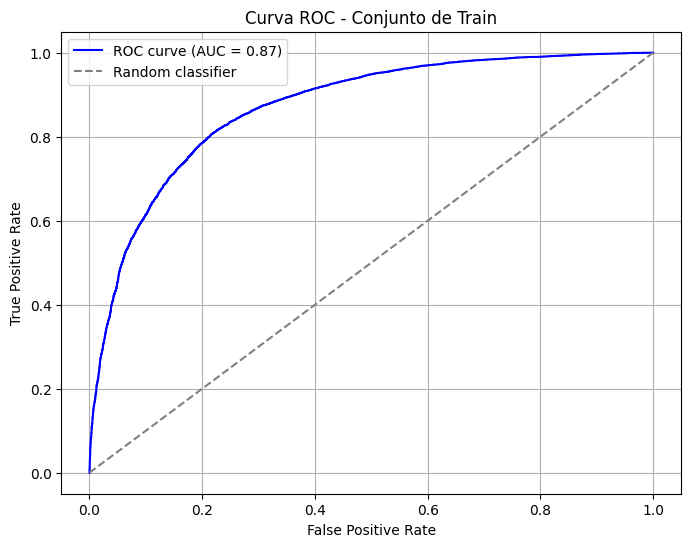

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades estimadas para la clase positiva
y_prob = grid_search.best_estimator_.predict_proba(X_train)[:, 1]

# Calcular FPR, TPR y umbrales
fpr, tpr, thresholds = roc_curve(y_train, y_prob)

# Calcular AUC
auc = roc_auc_score(y_train, y_prob)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Conjunto de Train')
plt.legend()
plt.grid(True)
plt.show()


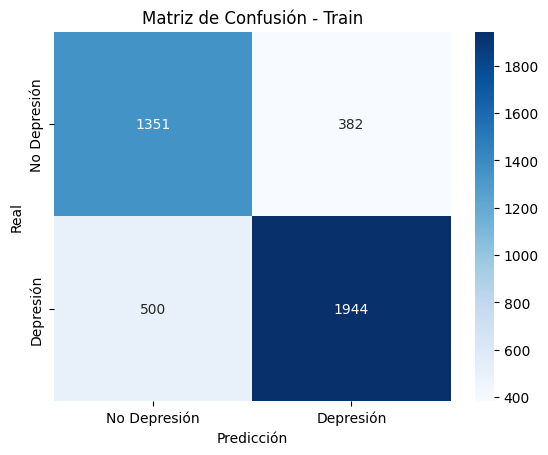


Reporte de clasificación (train):
              precision    recall  f1-score   support

No Depresión       0.74      0.78      0.76      8084
   Depresión       0.84      0.80      0.82     11404

    accuracy                           0.80     19488
   macro avg       0.79      0.79      0.79     19488
weighted avg       0.80      0.80      0.80     19488



In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Depresión', 'Depresión'], yticklabels=['No Depresión', 'Depresión'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Train')
plt.show()

# Clasificación detallada
print("\nReporte de clasificación (train):")
print(classification_report(y_train, y_pred_train, target_names=['No Depresión', 'Depresión']))


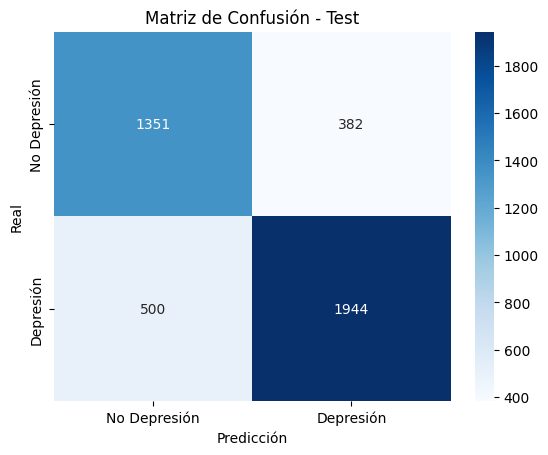


Reporte de clasificación (test):
              precision    recall  f1-score   support

No Depresión       0.73      0.78      0.75      1733
   Depresión       0.84      0.80      0.82      2444

    accuracy                           0.79      4177
   macro avg       0.78      0.79      0.78      4177
weighted avg       0.79      0.79      0.79      4177



In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Depresión', 'Depresión'], yticklabels=['No Depresión', 'Depresión'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Test')
plt.show()

# Clasificación detallada
print("\nReporte de clasificación (test):")
print(classification_report(y_test, y_pred_test, target_names=['No Depresión', 'Depresión']))


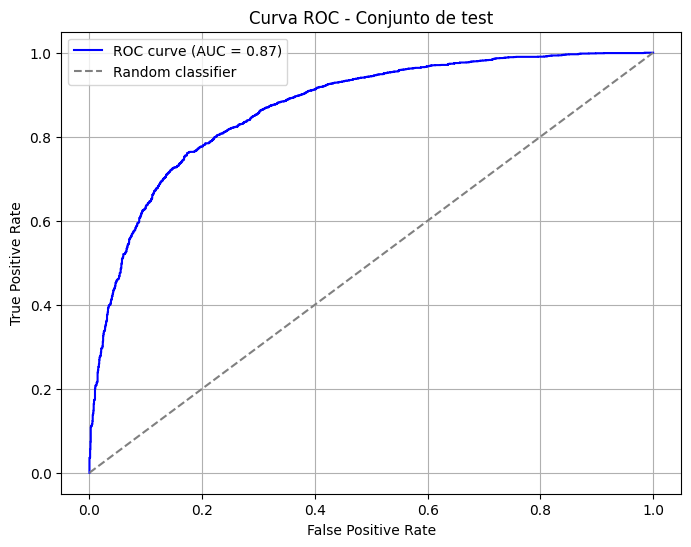

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades estimadas para la clase positiva
y_prob = grid_search.best_estimator_.predict_proba(X_test)[:, 1]

# Calcular FPR, TPR y umbrales
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular AUC
auc = roc_auc_score(y_test, y_prob)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Conjunto de test')
plt.legend()
plt.grid(True)
plt.show()


## Evaluando con el conjunto de validación



➡️ F1-score en validación: 0.815


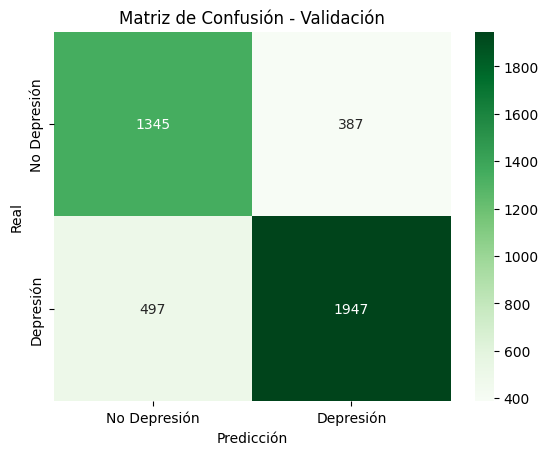


Reporte de clasificación (validación):
              precision    recall  f1-score   support

No Depresión       0.73      0.78      0.75      1732
   Depresión       0.83      0.80      0.81      2444

    accuracy                           0.79      4176
   macro avg       0.78      0.79      0.78      4176
weighted avg       0.79      0.79      0.79      4176



In [ ]:
# Predicción en conjunto de validación
y_pred_val = grid_search.best_estimator_.predict(X_val)

# Métrica F1
val_f1 = f1_score(y_val, y_pred_val)
print(f"\n➡️ F1-score en validación: {val_f1:.3f}")

# Matriz de confusión en validación
cm_val = confusion_matrix(y_val, y_pred_val)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Greens', xticklabels=['No Depresión', 'Depresión'], yticklabels=['No Depresión', 'Depresión'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Validación')
plt.show()

# Reporte de clasificación en validación
print("\nReporte de clasificación (validación):")
print(classification_report(y_val, y_pred_val, target_names=['No Depresión', 'Depresión']))


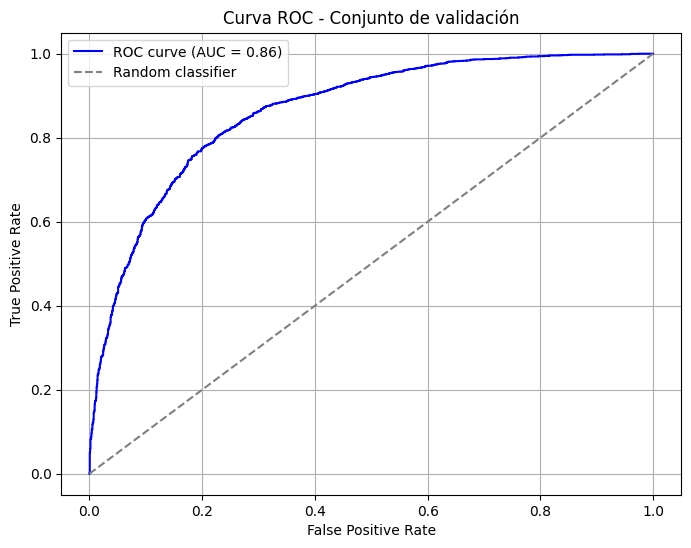

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades estimadas para la clase positiva
y_prob = grid_search.best_estimator_.predict_proba(X_val)[:, 1]

# Calcular FPR, TPR y umbrales
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

# Calcular AUC
auc = roc_auc_score(y_val, y_prob)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Conjunto de validación')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# prompt: grid_search guardar en pickle este modelo

import pickle

# Save the trained model to a pickle file
filename = 'logistic_regression_model.pkl'
pickle.dump(grid_search, open(filename, 'wb'))

print(f"Model saved to {filename}")

Model saved to logistic_regression_model.pkl


# **5. Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
ordinal_cols = ['degree_grouped', 'diet', 'sleep_hours', 'study_satisfaction_level_cat', 'cgpa_cat', 'financial_stress_cat', 'academic_pressure_cat']
ordinal_encoders = [degree_oe, diet_oe, sleep_oe, level_oe, level_oe, level_oe, level_oe]
categorical_cols = ['gender', 'city', 'mental_illness_history']

# Transformadores ordinales
ordinal_transformers = [(f'ord_{col}', enc, [col]) for col, enc in zip(ordinal_cols, ordinal_encoders)]

# Preprocesador
preprocessor_rf = ColumnTransformer(
    transformers=ordinal_transformers + [('ohe', ohe, categorical_cols)],
    remainder='passthrough'
)

# Pipeline con Random Forest
pipe_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_distributions = {
    'model__n_estimators': randint(100, 1000),
    'model__max_depth': [None] + list(range(5, 30, 5)),
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 20),
    'model__max_features': ['auto', 'sqrt', 'log2']
}


random_search_rf = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_distributions,
    scoring='f1',
    cv=5,
    n_iter=30,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [ ]:
random_search_rf.fit(X_train, y_train)

# Predicciones
y_pred_train = random_search_rf.predict(X_train)
y_pred_test = random_search_rf.predict(X_test)
y_pred_val = random_search_rf.predict(X_val)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, **l

✅ Mejor umbral (según F1): 0.41
📋 Reporte en conjunto de entrenamiento con mejor umbral:
              precision    recall  f1-score   support

       False       0.87      0.76      0.81      8084
        True       0.84      0.92      0.88     11404

    accuracy                           0.85     19488
   macro avg       0.86      0.84      0.84     19488
weighted avg       0.85      0.85      0.85     19488



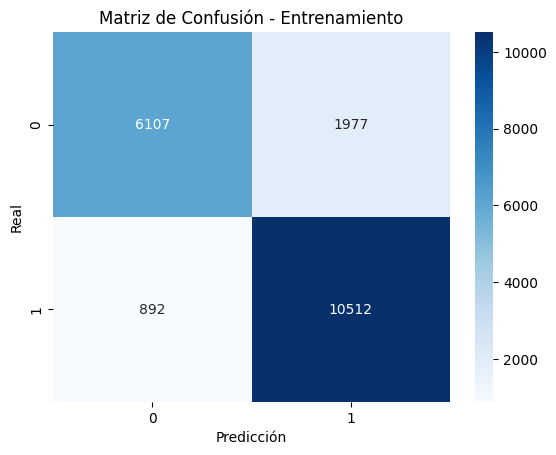

F1 (entrenamiento con mejor umbral): 0.880
AUC (entrenamiento): 0.935


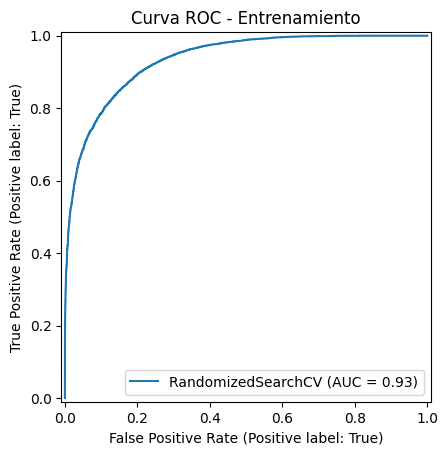

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, classification_report, RocCurveDisplay

# 1. Obtener probabilidades de clase 1
probs_train = random_search_rf.predict_proba(X_train)[:, 1]

# 2. Probar muchos umbrales
umbrales = np.linspace(0.0, 1.0, 101)
f1_scores = [f1_score(y_train, (probs_train >= u).astype(int)) for u in umbrales]

# 3. Elegir el mejor umbral según F1
mejor_umbral = umbrales[np.argmax(f1_scores)]
print(f"✅ Mejor umbral (según F1): {mejor_umbral:.2f}")

# 4. Predicciones con ese umbral
y_pred_train_umbral = (probs_train >= mejor_umbral).astype(int)

# Reporte
print("📋 Reporte en conjunto de entrenamiento con mejor umbral:")
print(classification_report(y_train, y_pred_train_umbral))

# Matriz de confusión
cm_train = confusion_matrix(y_train, y_pred_train_umbral)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Entrenamiento')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# F1 y AUC
f1_train = f1_score(y_train, y_pred_train_umbral)
auc_train = roc_auc_score(y_train, probs_train)
print(f'F1 (entrenamiento con mejor umbral): {f1_train:.3f}')
print(f'AUC (entrenamiento): {auc_train:.3f}')  # No depende del umbral

# Curva ROC
RocCurveDisplay.from_estimator(random_search_rf, X_train, y_train)
plt.title('Curva ROC - Entrenamiento')
plt.show()


✅ Mejor umbral (según F1): 0.45
📋 Reporte en conjunto de test con mejor umbral:
              precision    recall  f1-score   support

       False       0.77      0.72      0.75      1733
        True       0.81      0.85      0.83      2444

    accuracy                           0.80      4177
   macro avg       0.79      0.79      0.79      4177
weighted avg       0.80      0.80      0.80      4177



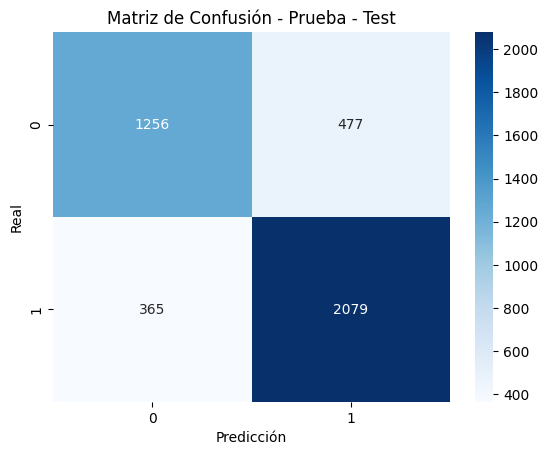

F1 (Test con mejor umbral): 0.832
AUC (Test): 0.868


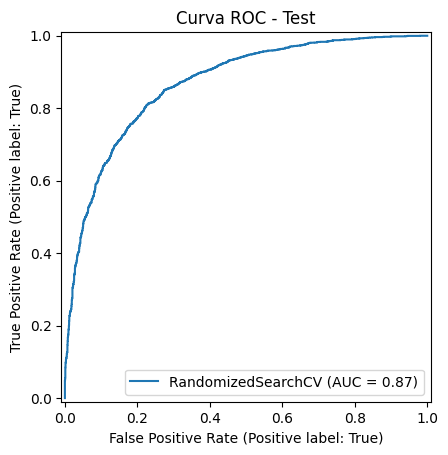

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, classification_report, RocCurveDisplay

# 1. Obtener probabilidades de clase 1
probs_test = random_search_rf.predict_proba(X_test)[:, 1]

# 2. Probar muchos umbrales
umbrales = np.linspace(0.0, 1.0, 101)
f1_scores = [f1_score(y_test, (probs_test >= u).astype(int)) for u in umbrales]

# 3. Elegir el mejor umbral según F1
mejor_umbral = umbrales[np.argmax(f1_scores)]
print(f"✅ Mejor umbral (según F1): {mejor_umbral:.2f}")

# 4. Predicciones con ese umbral
y_pred_test_umbral = (probs_test >= mejor_umbral).astype(int)

# Reporte
print("📋 Reporte en conjunto de test con mejor umbral:")
print(classification_report(y_test, y_pred_test_umbral))

# Matriz de confusión
cm_test= confusion_matrix(y_test, y_pred_test_umbral)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Prueba - Test')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# F1 y AUC
f1_test= f1_score(y_test, y_pred_test_umbral)
auc_test = roc_auc_score(y_test, probs_test)
print(f'F1 (Test con mejor umbral): {f1_test:.3f}')
print(f'AUC (Test): {auc_test:.3f}')  # No depende del umbral

# Curva ROC
RocCurveDisplay.from_estimator(random_search_rf, X_test, y_test)
plt.title('Curva ROC - Test')
plt.show()


✅ Mejor umbral (según F1): 0.41
📋 Reporte en conjunto de validacion con mejor umbral:
              precision    recall  f1-score   support

       False       0.79      0.67      0.73      1732
        True       0.79      0.88      0.83      2444

    accuracy                           0.79      4176
   macro avg       0.79      0.77      0.78      4176
weighted avg       0.79      0.79      0.79      4176



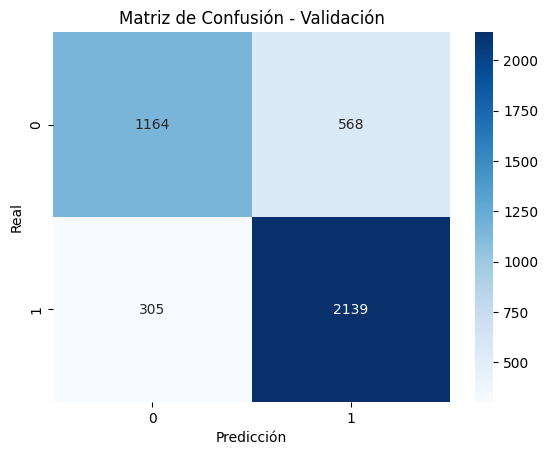

F1 (Val con mejor umbral): 0.831
AUC (Val): 0.863


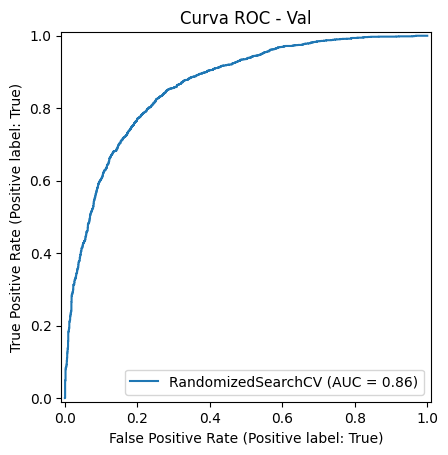

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, classification_report, RocCurveDisplay

# 1. Obtener probabilidades de clase 1
probs_val = random_search_rf.predict_proba(X_val)[:, 1]

# 2. Probar muchos umbrales
umbrales = np.linspace(0.0, 1.0, 101)
f1_scores = [f1_score(y_val, (probs_val >= u).astype(int)) for u in umbrales]

# 3. Elegir el mejor umbral según F1
mejor_umbral = umbrales[np.argmax(f1_scores)]
print(f"✅ Mejor umbral (según F1): {mejor_umbral:.2f}")

# 4. Predicciones con ese umbral
y_pred_val_umbral = (probs_val >= mejor_umbral).astype(int)

# Reporte
print("📋 Reporte en conjunto de validacion con mejor umbral:")
print(classification_report(y_val, y_pred_val_umbral))

# Matriz de confusión
cm_val= confusion_matrix(y_val, y_pred_val_umbral)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Validación')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# F1 y AUC
f1_val= f1_score(y_val, y_pred_val_umbral)
auc_val = roc_auc_score(y_val, probs_val)
print(f'F1 (Val con mejor umbral): {f1_val:.3f}')
print(f'AUC (Val): {auc_val:.3f}')  # No depende del umbral

# Curva ROC
RocCurveDisplay.from_estimator(random_search_rf, X_val, y_val)
plt.title('Curva ROC - Val')
plt.show()


In [ ]:
clf = random_search_rf.best_estimator_.named_steps['model']


# nombres de las características después de la transformación
feature_names = random_search_rf.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

# las importancias de las características (Gini importance)
importances = clf.feature_importances_

feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Gini Importance': importances
}).sort_values(by='Gini Importance', ascending=False)


feature_imp_df


,Feature,Gini Importance
6,ord_academic_pressure_cat__academic_pressure_cat,0.334578
5,ord_financial_stress_cat__financial_stress_cat,0.172943
38,remainder__age,0.095221
39,remainder__hours_dedicated,0.081639
1,ord_diet__diet,0.057841
3,ord_study_satisfaction_level_cat__study_satisf...,0.042633
0,ord_degree_grouped__degree_grouped,0.026666
2,ord_sleep_hours__sleep_hours,0.025473
37,ohe__mental_illness_history_Yes,0.009186
4,ord_cgpa_cat__cgpa_cat,0.007805


In [ ]:
import pickle

In [ ]:
import pickle

# Guardar el modelo
with open('modelo_random_forest.pkl', 'wb') as archivo:
    pickle.dump(random_search_rf, archivo)

In [ ]:
with open('modelo_random_forest.pkl', 'rb') as archivo:
    modelo_cargado = pickle.load(archivo)